## Data Loading & Dataset Splitting

This section covers loading the feature dataset generated in Phase 2 and isolating the official test set to prevent data leakage.

### Key Steps:
* **Drive Mounting & File Loading**: Mounts Google Drive and reads the feature dataset along with the official test filenames (`official_test_filenames_FOR_STUDENTS.csv`).
* **Official Test Set Isolation**: Separates rows corresponding to the official test set based on filenames, ensuring these samples are completely withheld during model development, parameter tuning, and validation to prevent **test-set tuning**.
* **Feature & Target Extraction**: Drops administrative columns (`filename`, `dialect`, `gender`, `speaker_id`) from the features matrix ($X_{cv}$) to ensure the model only relies on audio signal data.
* **Speaker Leakage Mitigation**: Group identifiers (`groups_cv`) are constructed combining file information and `speaker_id` to later facilitate a group-aware train/validation split, reducing the risk of speaker leakage.

In [ ]:
import os

import numpy as np
import pandas as pd
from google.colab import drive

drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/ML_Phase2_Processed"
features_path = os.path.join(base_path, "features_dataset.csv")
test_filenames_path = os.path.join(
    base_path, "official_test_filenames_FOR_STUDENTS.csv"
)

df_features = pd.read_csv(features_path)
df_test_filenames = pd.read_csv(test_filenames_path)

test_filenames_list = df_test_filenames["filename"].tolist()
df_test_official = df_features[df_features["filename"].isin(test_filenames_list)].copy()
df_remaining = df_features[~df_features["filename"].isin(test_filenames_list)].copy()

drop_cols = ["filename", "dialect", "gender", "speaker_id"]
X_cv = df_remaining.drop(columns=drop_cols)
y_cv_dialect = df_remaining["dialect"]
y_cv_gender = df_remaining["gender"]
groups_cv = (
    df_remaining["filename"].str.split("_").str[0] + "-" + df_remaining["speaker_id"]
).values

print(f"Total non-test samples : {len(df_remaining)}")
print(f"Features shape          : {X_cv.shape}")
print(f"Unique speaker groups   : {len(np.unique(groups_cv))}")
print(f"\nDialect distribution:\n{y_cv_dialect.value_counts()}")
print(f"\nGender distribution:\n{y_cv_gender.value_counts()}")


Mounted at /content/drive
Total non-test samples : 324
Features shape          : (324, 99)
Unique speaker groups   : 31

Dialect distribution:
dialect
Torki       97
Kordi       89
Gilaki      75
Isfahani    42
Mashhadi    21
Name: count, dtype: int64

Gender distribution:
gender
Female    170
Male      154
Name: count, dtype: int64


## Dependencies & Custom Progress Tracking Utilities

This block imports all required libraries and defines a utility context manager to enable progress bars during parallelized grid searches.

### Key Components:
* **Feature Processing & Dimensionality Reduction**: `StandardScaler` for normalization, `PCA` and `LinearDiscriminantAnalysis` (LDA) for dimensionality reduction, and `SelectKBest` for feature selection.
* **Class Imbalance Handling**: `SMOTE` from `imblearn` is included to handle potential dataset imbalances, paired with `ImbPipeline` to ensure preprocessing steps and oversampling are fit strictly on the training folds to avoid **Data Leakage**.
* **Machine Learning Classifiers**: Sets up the requested models including `KNeighborsClassifier` (KNN), `SVC` (SVM), `RandomForestClassifier`, and `MLPClassifier` (MLP).
* **Cross-Validation & Evaluation**: `StratifiedGroupKFold` is imported to enforce a cross-validation strategy that respects the group structure, explicitly mitigating the risk of **speaker leakage** by keeping the same speaker out of the training and validation splits simultaneously.
* **Progress Utilities (`tqdm_joblib`)**: Defines a context manager that dynamically patches `joblib`'s callback system. This enables real-time progress bars (`tqdm`) during extensive hyperparameter tuning sessions with `GridSearchCV`, providing clear visibility into execution states.

In [ ]:
import contextlib

import joblib
import matplotlib.pyplot as plt
from imblearn.over_sampling import SMOTE

# For the SMOTE-integrated pipeline
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    ParameterGrid,
    StratifiedGroupKFold,
    cross_val_predict,
)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import FeatureUnion, Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from tqdm.auto import tqdm

@contextlib.contextmanager
def tqdm_joblib(tqdm_object):
    """Patch joblib so GridSearchCV shows a tqdm progress bar."""

    class TqdmBatchCompletionCallback(joblib.parallel.BatchCompletionCallBack):
        def __call__(self, *args, **kwargs):
            tqdm_object.update(n=self.batch_size)
            return super().__call__(*args, **kwargs)

    old = joblib.parallel.BatchCompletionCallBack
    joblib.parallel.BatchCompletionCallBack = TqdmBatchCompletionCallback
    try:
        yield tqdm_object
    finally:
        joblib.parallel.BatchCompletionCallBack = old
        tqdm_object.close()

## Cross-Validation and Hyperparameter Tuning Framework

This block establishes a robust training and evaluation function (`train_evaluate_cv`) designed to search hyperparameter spaces while enforcing strict safeguards against data leakage.

### Key Architecture Components:

* **Dynamic Preprocessing Pipelines (`Pipeline` & `FeatureUnion`)**:
    * **Standard Scenarios**: Data is sequentially normalized via `StandardScaler`, passed through ANOVA-based feature selection (`SelectKBest`), and fed to the classifier.
    * **Advanced Scenarios (`use_lda=True`)**: Employs a parallel feature engineering layout via `FeatureUnion`. It extracts features simultaneously using supervised `LinearDiscriminantAnalysis` and unsupervised `PCA` (with optional ANOVA branches) to create a comprehensive multi-perspective feature embedding before classification.
* **Leakage-Free Transformations**: All operations—including scaling, feature selection, and dimension reduction—are encapsulated inside a Scikit-Learn `Pipeline`. This ensures they are fit strictly on the training folds of each split and only transformed onto the validation folds, preventing data leakage.
* **Speaker-Group Validation Structure**: Utilizes `StratifiedGroupKFold` with 5 splits to ensure that all samples from any single speaker are exclusively kept together in either the training or the validation pool, directly addressing speaker leakage concerns.
* **Performance Metrics & Error Diagnosis**: Evaluates models using Out-Of-Fold (OOF) predictions. It computes crucial classification metrics required by the project phase, including Accuracy, Precision, Recall, and Macro F1-score. It also plots a detailed `ConfusionMatrixDisplay` and produces a full classification report to facilitate error analysis.

In [ ]:
def train_evaluate_cv(
    estimator, param_grid, X, y, groups, title, use_lda=False, use_anova_branch=False
):

    print(f"\n{'=' * 16} {title} {'=' * 16}")

    if use_lda:
        # Build the parallel FeatureUnion branches
        branches = [
            ("lda", LinearDiscriminantAnalysis()),
            ("pca", PCA()),  # n_components tuned by GridSearch
        ]
        if use_anova_branch:
            # third branch — top-m ANOVA features, m tuned by GridSearch
            branches.append(("anova", SelectKBest(score_func=f_classif)))
        reducer = FeatureUnion(branches)
        steps = [
            ("scaler", StandardScaler()),
            ("feat", reducer),
            ("model", estimator),
        ]
    else:
        steps = [
            ("scaler", StandardScaler()),
            ("feature_selection", SelectKBest(score_func=f_classif)),
            ("model", estimator),
        ]

    pipeline = Pipeline(steps)
    cv = StratifiedGroupKFold(n_splits=5)
    n_fits = len(ParameterGrid(param_grid)) * cv.get_n_splits(X, y, groups)

    grid = GridSearchCV(pipeline, param_grid, cv=cv, scoring="f1_macro", n_jobs=2)
    with tqdm_joblib(tqdm(desc=f"Tuning {title}", total=n_fits)):
        grid.fit(X, y, groups=groups)

    best_model = grid.best_estimator_
    print(f"Best Parameters    : {grid.best_params_}")
    print(f"Best CV F1-macro   : {grid.best_score_:.4f}")

    oof_preds = cross_val_predict(best_model, X, y, groups=groups, cv=cv, n_jobs=2)

    acc = accuracy_score(y, oof_preds)
    prec = precision_score(y, oof_preds, average="macro", zero_division=0)
    rec = recall_score(y, oof_preds, average="macro", zero_division=0)
    f1 = f1_score(y, oof_preds, average="macro", zero_division=0)

    print(f"OOF Accuracy  : {acc:.4f}")
    print(f"OOF Precision : {prec:.4f}")
    print(f"OOF Recall    : {rec:.4f}")
    print(f"OOF F1-macro  : {f1:.4f}")
    print("\nPer-class breakdown:")
    print(classification_report(y, oof_preds, zero_division=0))

    cm = confusion_matrix(y, oof_preds, labels=best_model.classes_)
    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm, display_labels=best_model.classes_
    )
    disp.plot(cmap=plt.cm.Blues, xticks_rotation="vertical")
    plt.title(f"{title} — OOF Confusion Matrix")
    plt.tight_layout()
    plt.show()

    return best_model, grid.best_params_

## Hyperparameter Search Grids Configuration

This block defines the hyperparameter search spaces (`param_grid`) for the four candidate classification algorithms across different feature extraction pipelines, addressing the task requirements.

### Grid Categories:

* **Gender Classification Grids (`SelectKBest` Pipeline)**:
    * Designed for a sequential feature-selection workflow.
    * Explores varying quantities of raw acoustic features (`feature_selection__k` up to all) alongside model-specific architectural configurations.
* **Dialect Classification Grids (Dual `LDA` + `PCA` Pipeline)**:
    * Tailored for a multi-perspective feature space combining unsupervised structural variances (`PCA`) and supervised class separability (`LinearDiscriminantAnalysis`).
    * Optimizes the number of principal components (`feat__pca__n_components`) simultaneously with downstream model parameters, testing both linear and non-linear boundaries (such as `rbf` and `poly` kernels for SVM).
* **Dialect Classification Grids (Triple `LDA` + `PCA` + `ANOVA` Pipeline)**:
    * Extends the feature extraction pipeline by adding a third parallel branch using ANOVA-based univariant selection (`SelectKBest`).
    * Concurrently tunes latent component projection counts (`n_pca_triple`) and raw feature counts (`feat__anova__k`), yielding a richer descriptor space spanning global variance, class discrimination, and specific localized audio features.

In [ ]:
k_options = [15, 30, 50, 75, "all"]

# --- Gender grids (SelectKBest pipeline) ---
knn_params_gender = {
    "feature_selection__k": k_options,
    "model__n_neighbors": [3, 5, 7, 9, 11],
}
svm_params_gender = {
    "feature_selection__k": k_options,
    "model__kernel": ["rbf"],
    "model__C": [1, 10, 100],
    "model__gamma": ["scale", "auto"],
}
rf_params_gender = {
    "feature_selection__k": k_options,
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 20],
    "model__min_samples_leaf": [1, 2],
}
mlp_params_gender = {
    "feature_selection__k": k_options,
    "model__hidden_layer_sizes": [(100,), (128, 64)],
    "model__learning_rate_init": [0.001],
}

# --- Dialect grids (LDA+PCA FeatureUnion pipeline) ----
# 'feat__pca__n_components' tunes how many PCA components to add alongside
# The list-of-dicts form lets GridSearchCV search rbf and poly jointly.
n_pca_options = [5, 10, 15, 20, 25, 30]

knn_params_dialect = {
    "feat__pca__n_components": n_pca_options,
    "model__n_neighbors": [3, 5, 7, 9, 11],
}
svm_params_dialect = [
    # RBF kernel
    {
        "feat__pca__n_components": n_pca_options,
        "model__kernel": ["rbf"],
        "model__C": [1, 5, 10, 50, 100],
        "model__gamma": ["scale", "auto"],
    },
    # Polynomial kernel — empirically best in LDA+PCA space
    {
        "feat__pca__n_components": n_pca_options,
        "model__kernel": ["poly"],
        "model__C": [0.5, 1, 2, 5, 10],
        "model__degree": [2, 3],
    },
]
rf_params_dialect = {
    "feat__pca__n_components": n_pca_options,
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2],
}
mlp_params_dialect = {
    "feat__pca__n_components": n_pca_options,
    "model__hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
    "model__learning_rate_init": [0.001, 0.01],
}

# --- Dialect grids (triple FeatureUnion: LDA+PCA+ANOVA) ---
# Adds a third ANOVA branch: SelectKBest keeps the m most individually
# class-discriminant raw features ALONGSIDE LDA and PCA projections.
# Grid searches n_pca and n_anova jointly with SVM hyperparameters.
# Total output dim = 4 (LDA) + n_pca (PCA) + n_anova (ANOVA), e.g. 4+10+20=34.
n_pca_triple = [5, 10, 15, 20]  # PCA components for triple branch search
n_anova_options = [10, 20, 30]  # ANOVA top-k features for triple branch

knn_params_dialect_triple = {
    "feat__pca__n_components": n_pca_triple,
    "feat__anova__k": n_anova_options,
    "model__n_neighbors": [3, 5, 7, 9, 11],
}
svm_params_dialect_triple = [
    {
        "feat__pca__n_components": n_pca_triple,
        "feat__anova__k": n_anova_options,
        "model__kernel": ["rbf"],
        "model__C": [1, 5, 10, 50],
        "model__gamma": ["scale", "auto"],
    },
    {
        "feat__pca__n_components": n_pca_triple,
        "feat__anova__k": n_anova_options,
        "model__kernel": ["poly"],
        "model__C": [0.5, 1, 2, 5, 10],
        "model__degree": [2, 3],
    },
]
rf_params_dialect_triple = {
    "feat__pca__n_components": n_pca_triple,
    "feat__anova__k": n_anova_options,
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_leaf": [1, 2],
}
mlp_params_dialect_triple = {
    "feat__pca__n_components": n_pca_triple,
    "feat__anova__k": n_anova_options,
    "model__hidden_layer_sizes": [(64,), (64, 32), (128, 64)],
    "model__learning_rate_init": [0.001, 0.01],
}

## Gender Classification Model Training & Evaluation

This block executes the independent classification pipeline for the **Gender Detection** task. It trains and evaluates four distinct machine learning models to identify a baseline and optimize speaker-independent performance.

### Execution Details:
* **Algorithms Trained**: K-Nearest Neighbors (KNN), Support Vector Machine (SVM), Random Forest, and Multi-Layer Perceptron (MLP).
* **Feature Pipeline**: Implements the sequential `SelectKBest` ANOVA feature selection layout (`use_lda=False`), ensuring feature choices are tuned cross-validation fold by cross-validation fold.
* **Class Imbalance & Robustness**: For models sensitive to distribution skew (SVM and Random Forest), `class_weight="balanced"` is enabled to counteract variations in the training splits.
* **Reproducibility**: Static `random_state=42` anchors are asserted across all stochastic estimators to satisfy strict project reproducibility standards.
* **Metrics Tracked**: Evaluates Out-Of-Fold macro-averaged and per-class targets to determine the leading model architecture based on overall precision, recall, and confusion matrix topologies.

RUNNING GENDER CLASSIFICATION

================ KNN — Gender ================


Tuning KNN — Gender:   0%|          | 0/125 [00:00<?, ?it/s]

Best Parameters    : {'feature_selection__k': 30, 'model__n_neighbors': 7}
Best CV F1-macro   : 0.8124
OOF Accuracy  : 0.8117
OOF Precision : 0.8112
OOF Recall    : 0.8114
OOF F1-macro  : 0.8113

Per-class breakdown:
              precision    recall  f1-score   support

      Female       0.82      0.82      0.82       170
        Male       0.80      0.81      0.80       154

    accuracy                           0.81       324
   macro avg       0.81      0.81      0.81       324
weighted avg       0.81      0.81      0.81       324



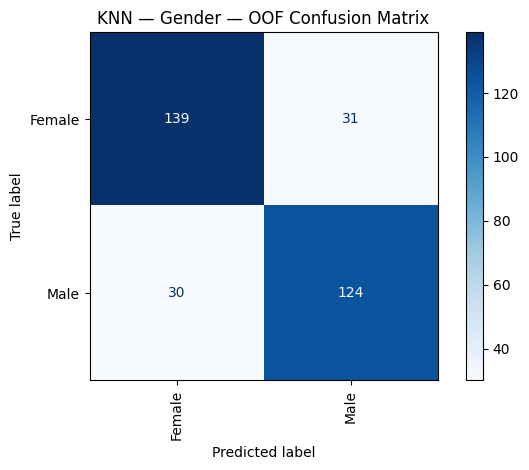


================ SVM — Gender ================


Tuning SVM — Gender:   0%|          | 0/150 [00:00<?, ?it/s]

Best Parameters    : {'feature_selection__k': 50, 'model__C': 1, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV F1-macro   : 0.8491
OOF Accuracy  : 0.8488
OOF Precision : 0.8489
OOF Recall    : 0.8498
OOF F1-macro  : 0.8487

Per-class breakdown:
              precision    recall  f1-score   support

      Female       0.88      0.83      0.85       170
        Male       0.82      0.87      0.85       154

    accuracy                           0.85       324
   macro avg       0.85      0.85      0.85       324
weighted avg       0.85      0.85      0.85       324



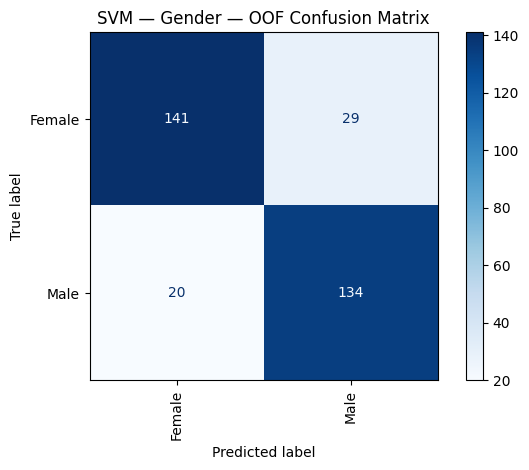


================ Random Forest — Gender ================


Tuning Random Forest — Gender:   0%|          | 0/200 [00:00<?, ?it/s]

Best Parameters    : {'feature_selection__k': 50, 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__n_estimators': 200}
Best CV F1-macro   : 0.9047
OOF Accuracy  : 0.9043
OOF Precision : 0.9040
OOF Recall    : 0.9042
OOF F1-macro  : 0.9041

Per-class breakdown:
              precision    recall  f1-score   support

      Female       0.91      0.91      0.91       170
        Male       0.90      0.90      0.90       154

    accuracy                           0.90       324
   macro avg       0.90      0.90      0.90       324
weighted avg       0.90      0.90      0.90       324



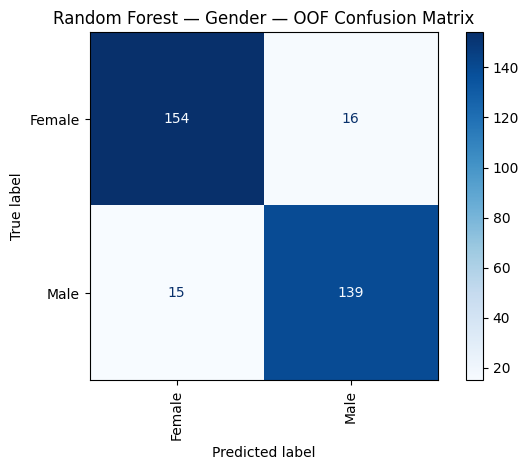


================ MLP — Gender ================


Tuning MLP — Gender:   0%|          | 0/50 [00:00<?, ?it/s]

Best Parameters    : {'feature_selection__k': 50, 'model__hidden_layer_sizes': (100,), 'model__learning_rate_init': 0.001}
Best CV F1-macro   : 0.8391
OOF Accuracy  : 0.8395
OOF Precision : 0.8416
OOF Recall    : 0.8416
OOF F1-macro  : 0.8395

Per-class breakdown:
              precision    recall  f1-score   support

      Female       0.88      0.80      0.84       170
        Male       0.80      0.88      0.84       154

    accuracy                           0.84       324
   macro avg       0.84      0.84      0.84       324
weighted avg       0.84      0.84      0.84       324



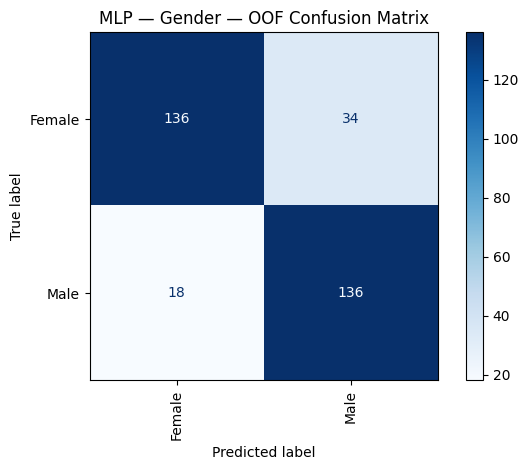

In [ ]:
print("=" * 60)
print("RUNNING GENDER CLASSIFICATION")
print("=" * 60)

best_knn_gender = train_evaluate_cv(
    KNeighborsClassifier(),
    knn_params_gender,
    X_cv,
    y_cv_gender,
    groups_cv,
    "KNN — Gender",
    use_lda=False,
)

best_svm_gender = train_evaluate_cv(
    SVC(random_state=42, class_weight="balanced"),
    svm_params_gender,
    X_cv,
    y_cv_gender,
    groups_cv,
    "SVM — Gender",
    use_lda=False,
)

best_rf_gender = train_evaluate_cv(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_params_gender,
    X_cv,
    y_cv_gender,
    groups_cv,
    "Random Forest — Gender",
    use_lda=False,
)

best_mlp_gender = train_evaluate_cv(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp_params_gender,
    X_cv,
    y_cv_gender,
    groups_cv,
    "MLP — Gender",
    use_lda=False,
)

## Dialect Classification — Baseline Evaluation

This block trains and evaluates the baseline configurations for the **Dialect Classification** task using standard univariate feature selection.

### Execution Details:
* **Baseline Purpose**: Establishes a foundational performance baseline using standard `SelectKBest` feature selection without structural projection methods. This provides a direct point of comparison to quantify the performance gains of more advanced feature-fusion strategies.
* **Algorithms Evaluated**: K-Nearest Neighbors (KNN) and Support Vector Machine (SVM).
* **Expected Constraints**: Due to the complex nature of dialect differences in acoustic signals, a simple univariate filter method (`SelectKBest`) often struggles to isolate class boundaries, typically yielding lower cross-validation scores.
* **Leakage-Free Validation**: Maintains strict structural separation by utilizing the group-aware framework, ensuring no individual speaker's audio clips are shared between training and validation splits.

DIALECT CLASSIFICATION — BASELINE (SelectKBest)
Expected: ~20% accuracy — shown here only for comparison

================ KNN — Dialect (baseline) ================


Tuning KNN — Dialect (baseline):   0%|          | 0/125 [00:00<?, ?it/s]

Best Parameters    : {'feature_selection__k': 30, 'model__n_neighbors': 3}
Best CV F1-macro   : 0.2036
OOF Accuracy  : 0.2037
OOF Precision : 0.2106
OOF Recall    : 0.2039
OOF F1-macro  : 0.2042

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.36      0.32      0.34        75
    Isfahani       0.19      0.24      0.21        42
       Kordi       0.18      0.24      0.21        89
    Mashhadi       0.21      0.14      0.17        21
       Torki       0.10      0.08      0.09        97

    accuracy                           0.20       324
   macro avg       0.21      0.20      0.20       324
weighted avg       0.20      0.20      0.20       324



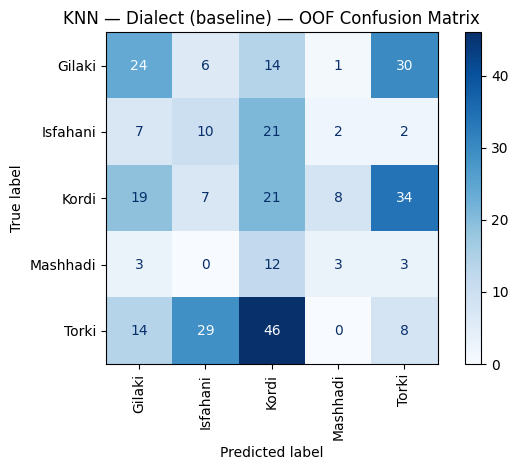


================ SVM — Dialect (baseline) ================


Tuning SVM — Dialect (baseline):   0%|          | 0/150 [00:00<?, ?it/s]

Best Parameters    : {'feature_selection__k': 15, 'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'rbf'}
Best CV F1-macro   : 0.1615
OOF Accuracy  : 0.2222
OOF Precision : 0.2032
OOF Recall    : 0.1905
OOF F1-macro  : 0.1942

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.34      0.36      0.35        75
    Isfahani       0.30      0.19      0.23        42
       Kordi       0.25      0.25      0.25        89
    Mashhadi       0.00      0.00      0.00        21
       Torki       0.12      0.15      0.14        97

    accuracy                           0.22       324
   macro avg       0.20      0.19      0.19       324
weighted avg       0.22      0.22      0.22       324



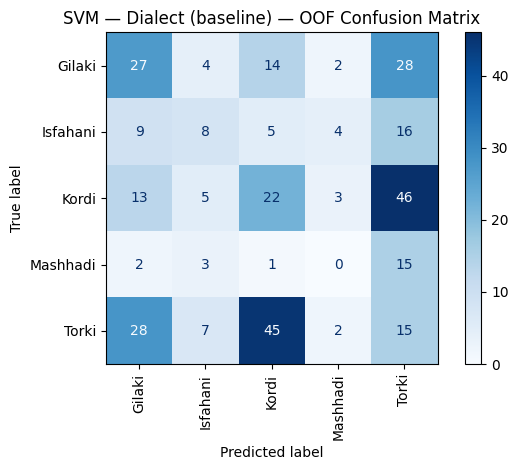

In [ ]:
print("=" * 60)
print("DIALECT CLASSIFICATION — BASELINE (SelectKBest)")
print("Expected: ~20% accuracy — shown here only for comparison")
print("=" * 60)

best_knn_dialect_base = train_evaluate_cv(
    KNeighborsClassifier(),
    knn_params_gender,  # reuse gender grid (has k options)
    X_cv,
    y_cv_dialect,
    groups_cv,
    "KNN — Dialect (baseline)",
    use_lda=False,
)

best_svm_dialect_base = train_evaluate_cv(
    SVC(random_state=42, class_weight="balanced"),
    svm_params_gender,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "SVM — Dialect (baseline)",
    use_lda=False,
)

## Dialect Classification — Advanced Feature Fusion (LDA + PCA)

This block runs the advanced classification pipeline for the **Dialect Classification** task by utilizing a dual feature-extraction space.

### Execution Details:
* **Feature Extraction Framework (`use_lda=True`)**: Implements a parallel `FeatureUnion` consisting of unsupervised Principal Component Analysis (PCA) and supervised Linear Discriminant Analysis (LDA). This combines global variance mapping with class-discriminant maximizing projections.
* **Hyperparameter Tuning**: Co-optimizes the down-stream model settings along with the optimal structural depth of the projection space by checking a range of PCA components (`n_pca_options`).
* **Algorithms Evaluated**: K-Nearest Neighbors (KNN), Support Vector Machine (SVM) exploring both polynomial and radial basis function kernels, Random Forest, and Multi-Layer Perceptron (MLP).
* **Robust Process Control**: Preprocessing parameters, projection bases, and model weights are fit entirely within individual cross-validation loops via Scikit-Learn pipelines, ensuring zero information leakage into validation splits.

DIALECT CLASSIFICATION — 7a: LDA + PCA (expanded PCA range)
PCA n_components searched over: [5, 10, 15, 20, 25, 30]

================ KNN — Dialect (LDA+PCA) ================


Tuning KNN — Dialect (LDA+PCA):   0%|          | 0/150 [00:00<?, ?it/s]

Best Parameters    : {'feat__pca__n_components': 5, 'model__n_neighbors': 7}
Best CV F1-macro   : 0.2590
OOF Accuracy  : 0.3519
OOF Precision : 0.3216
OOF Recall    : 0.3059
OOF F1-macro  : 0.3063

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.61      0.61      0.61        75
    Isfahani       0.32      0.29      0.30        42
       Kordi       0.20      0.19      0.19        89
    Mashhadi       0.17      0.05      0.07        21
       Torki       0.32      0.39      0.36        97

    accuracy                           0.35       324
   macro avg       0.32      0.31      0.31       324
weighted avg       0.34      0.35      0.34       324



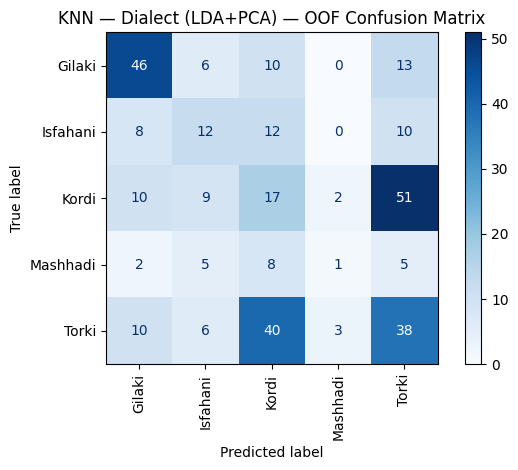


================ SVM — Dialect (LDA+PCA, poly+rbf grid) ================


Tuning SVM — Dialect (LDA+PCA, poly+rbf grid):   0%|          | 0/600 [00:00<?, ?it/s]

Best Parameters    : {'feat__pca__n_components': 5, 'model__C': 5, 'model__degree': 2, 'model__kernel': 'poly'}
Best CV F1-macro   : 0.4072
OOF Accuracy  : 0.4475
OOF Precision : 0.3462
OOF Recall    : 0.3474
OOF F1-macro  : 0.3365

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.52      0.43      0.47        75
    Isfahani       0.32      0.17      0.22        42
       Kordi       0.40      0.62      0.49        89
    Mashhadi       0.00      0.00      0.00        21
       Torki       0.50      0.53      0.51        97

    accuracy                           0.45       324
   macro avg       0.35      0.35      0.34       324
weighted avg       0.42      0.45      0.42       324



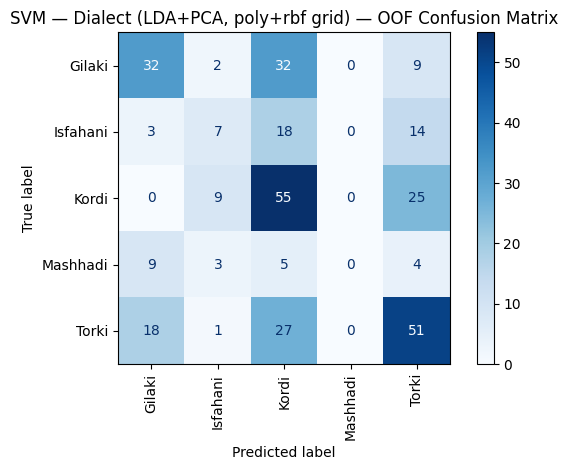


================ Random Forest — Dialect (LDA+PCA) ================


Tuning Random Forest — Dialect (LDA+PCA):   0%|          | 0/540 [00:00<?, ?it/s]

Best Parameters    : {'feat__pca__n_components': 20, 'model__max_depth': 10, 'model__min_samples_leaf': 1, 'model__n_estimators': 100}
Best CV F1-macro   : 0.2674
OOF Accuracy  : 0.3765
OOF Precision : 0.3190
OOF Recall    : 0.3073
OOF F1-macro  : 0.3059

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.62      0.52      0.57        75
    Isfahani       0.24      0.19      0.21        42
       Kordi       0.21      0.19      0.20        89
    Mashhadi       0.11      0.05      0.07        21
       Torki       0.41      0.59      0.48        97

    accuracy                           0.38       324
   macro avg       0.32      0.31      0.31       324
weighted avg       0.36      0.38      0.36       324



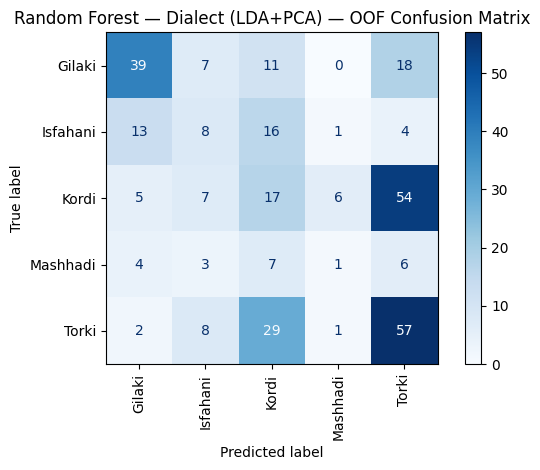


================ MLP — Dialect (LDA+PCA) ================


Tuning MLP — Dialect (LDA+PCA):   0%|          | 0/180 [00:00<?, ?it/s]

Best Parameters    : {'feat__pca__n_components': 20, 'model__hidden_layer_sizes': (64,), 'model__learning_rate_init': 0.001}
Best CV F1-macro   : 0.2901
OOF Accuracy  : 0.3765
OOF Precision : 0.3390
OOF Recall    : 0.3247
OOF F1-macro  : 0.3277

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.65      0.60      0.62        75
    Isfahani       0.37      0.31      0.34        42
       Kordi       0.22      0.20      0.21        89
    Mashhadi       0.10      0.05      0.06        21
       Torki       0.35      0.46      0.40        97

    accuracy                           0.38       324
   macro avg       0.34      0.32      0.33       324
weighted avg       0.37      0.38      0.37       324



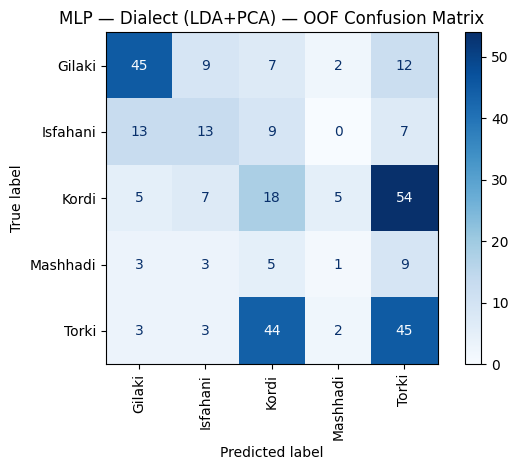

In [ ]:
print("=" * 60)
print("DIALECT CLASSIFICATION — 7a: LDA + PCA (expanded PCA range)")
print("PCA n_components searched over:", n_pca_options)
print("=" * 60)

best_knn_dialect, best_knn_dialect_params = train_evaluate_cv(
    KNeighborsClassifier(),
    knn_params_dialect,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "KNN — Dialect (LDA+PCA)",
    use_lda=True,
)

best_svm_dialect, best_svm_dialect_params = train_evaluate_cv(
    SVC(random_state=42, class_weight="balanced"),
    svm_params_dialect,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "SVM — Dialect (LDA+PCA, poly+rbf grid)",
    use_lda=True,
)

best_rf_dialect, best_rf_dialect_params = train_evaluate_cv(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_params_dialect,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "Random Forest — Dialect (LDA+PCA)",
    use_lda=True,
)

best_mlp_dialect, best_mlp_dialect_params = train_evaluate_cv(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp_params_dialect,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "MLP — Dialect (LDA+PCA)",
    use_lda=True,
)

## Dialect Classification — Triple Feature Fusion & Model Selection Summary

This block evaluates an extended dialect classification pipeline and concludes the dialect model discovery stage by benchmarking all combinations.

### Execution Details:
* **Triple Feature-Fusion Architecture (`use_anova_branch=True`)**: Implements an expanded `FeatureUnion` consisting of three concurrent extraction streams:
    1. **Supervised Latent Projection**: Linear Discriminant Analysis (LDA) to maximize class separability.
    2. **Unsupervised Dimensionality Reduction**: Principal Component Analysis (PCA) to retain global signal variance.
    3. **Univariate Feature Selection**: An ANOVA filter (`SelectKBest`) to feed the highest scoring individual acoustic features directly to the learner alongside projections.
* **Co-Optimization**: Simultaneously sweeps optimal PCA target components and ANOVA univariant feature limits alongside down-stream model hyper-parameters.
* **Comprehensive Performance Benchmark**: Concludes with an iterative evaluation loop across all eight advanced structural configurations (Dual-Branch vs. Triple-Branch across four core algorithms). Out-Of-Fold accuracy and macro-averaged F1-scores are displayed in a clean comparative layout to objectively isolate the best architecture for final deployment.

DIALECT CLASSIFICATION — 7b: TRIPLE LDA + PCA + ANOVA
PCA range: [5, 10, 15, 20]    ANOVA-k range: [10, 20, 30]

================ KNN — Dialect (LDA+PCA+ANOVA) ================


Tuning KNN — Dialect (LDA+PCA+ANOVA):   0%|          | 0/300 [00:00<?, ?it/s]

Best Parameters    : {'feat__anova__k': 30, 'feat__pca__n_components': 5, 'model__n_neighbors': 5}
Best CV F1-macro   : 0.2593
OOF Accuracy  : 0.3395
OOF Precision : 0.3490
OOF Recall    : 0.3101
OOF F1-macro  : 0.3185

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.57      0.56      0.56        75
    Isfahani       0.29      0.29      0.29        42
       Kordi       0.20      0.19      0.20        89
    Mashhadi       0.38      0.14      0.21        21
       Torki       0.31      0.37      0.33        97

    accuracy                           0.34       324
   macro avg       0.35      0.31      0.32       324
weighted avg       0.34      0.34      0.34       324



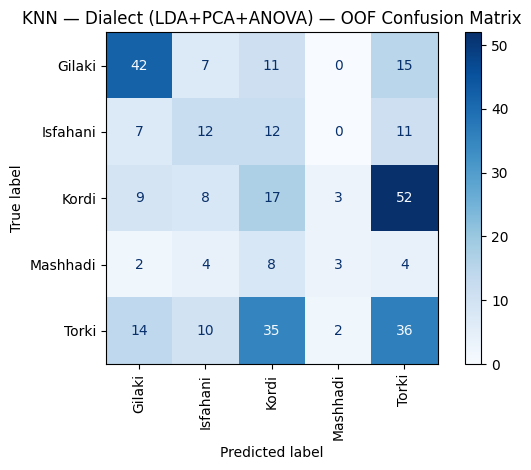


================ SVM — Dialect (LDA+PCA+ANOVA, poly+rbf) ================


Tuning SVM — Dialect (LDA+PCA+ANOVA, poly+rbf):   0%|          | 0/1080 [00:00<?, ?it/s]

Best Parameters    : {'feat__anova__k': 20, 'feat__pca__n_components': 5, 'model__C': 2, 'model__degree': 2, 'model__kernel': 'poly'}
Best CV F1-macro   : 0.3820
OOF Accuracy  : 0.4660
OOF Precision : 0.3637
OOF Recall    : 0.3585
OOF F1-macro  : 0.3475

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.57      0.45      0.50        75
    Isfahani       0.32      0.14      0.20        42
       Kordi       0.39      0.63      0.48        89
    Mashhadi       0.00      0.00      0.00        21
       Torki       0.55      0.57      0.56        97

    accuracy                           0.47       324
   macro avg       0.36      0.36      0.35       324
weighted avg       0.44      0.47      0.44       324



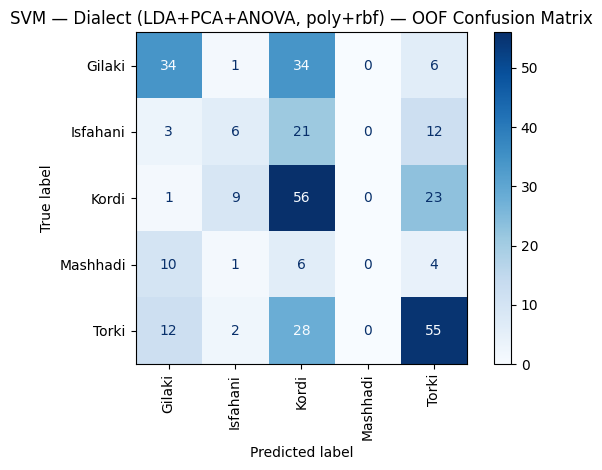


================ Random Forest — Dialect (LDA+PCA+ANOVA) ================


Tuning Random Forest — Dialect (LDA+PCA+ANOVA):   0%|          | 0/1080 [00:00<?, ?it/s]

Best Parameters    : {'feat__anova__k': 30, 'feat__pca__n_components': 10, 'model__max_depth': None, 'model__min_samples_leaf': 2, 'model__n_estimators': 100}
Best CV F1-macro   : 0.2791
OOF Accuracy  : 0.3673
OOF Precision : 0.3566
OOF Recall    : 0.3078
OOF F1-macro  : 0.3155

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.68      0.55      0.61        75
    Isfahani       0.36      0.24      0.29        42
       Kordi       0.20      0.19      0.19        89
    Mashhadi       0.20      0.05      0.08        21
       Torki       0.34      0.52      0.41        97

    accuracy                           0.37       324
   macro avg       0.36      0.31      0.32       324
weighted avg       0.37      0.37      0.36       324



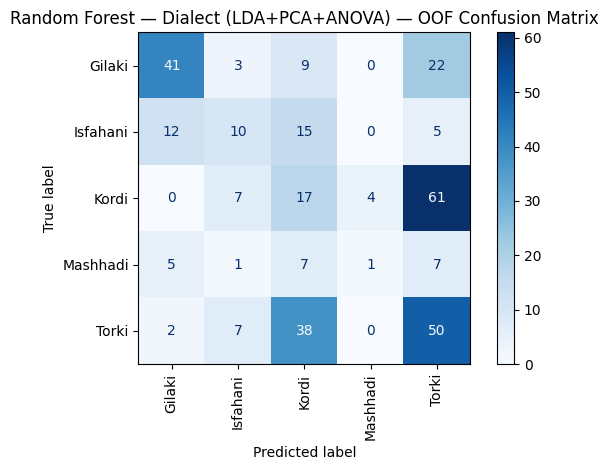


================ MLP — Dialect (LDA+PCA+ANOVA) ================


Tuning MLP — Dialect (LDA+PCA+ANOVA):   0%|          | 0/360 [00:00<?, ?it/s]

Best Parameters    : {'feat__anova__k': 10, 'feat__pca__n_components': 5, 'model__hidden_layer_sizes': (64, 32), 'model__learning_rate_init': 0.01}
Best CV F1-macro   : 0.2891
OOF Accuracy  : 0.3827
OOF Precision : 0.3986
OOF Recall    : 0.3450
OOF F1-macro  : 0.3581

Per-class breakdown:
              precision    recall  f1-score   support

      Gilaki       0.67      0.56      0.61        75
    Isfahani       0.37      0.33      0.35        42
       Kordi       0.25      0.22      0.24        89
    Mashhadi       0.38      0.14      0.21        21
       Torki       0.34      0.46      0.39        97

    accuracy                           0.38       324
   macro avg       0.40      0.34      0.36       324
weighted avg       0.39      0.38      0.38       324



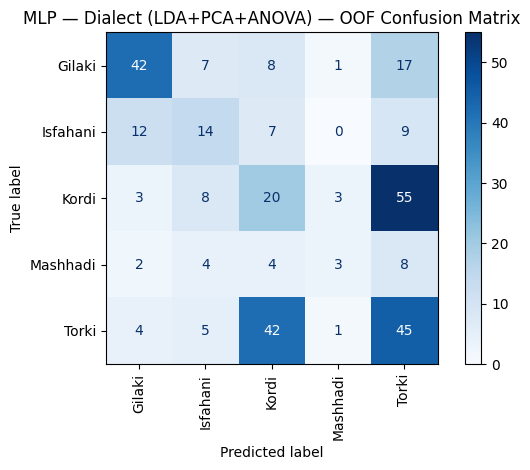


DIALECT ACCURACY SUMMARY
  KNN  LDA+PCA               OOF Acc=0.3519  F1-macro=0.3063
  SVM  LDA+PCA               OOF Acc=0.4475  F1-macro=0.3365
  RF   LDA+PCA               OOF Acc=0.3765  F1-macro=0.3059
  MLP  LDA+PCA               OOF Acc=0.3765  F1-macro=0.3277
  KNN  LDA+PCA+ANOVA         OOF Acc=0.3395  F1-macro=0.3185
  SVM  LDA+PCA+ANOVA         OOF Acc=0.4660  F1-macro=0.3475
  RF   LDA+PCA+ANOVA         OOF Acc=0.3673  F1-macro=0.3155
  MLP  LDA+PCA+ANOVA         OOF Acc=0.3827  F1-macro=0.3581


In [ ]:
print("=" * 60)
print("DIALECT CLASSIFICATION — 7b: TRIPLE LDA + PCA + ANOVA")
print(f"PCA range: {n_pca_triple}    ANOVA-k range: {n_anova_options}")
print("=" * 60)

best_knn_dialect_triple, best_knn_dialect_triple_params = train_evaluate_cv(
    KNeighborsClassifier(),
    knn_params_dialect_triple,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "KNN — Dialect (LDA+PCA+ANOVA)",
    use_lda=True,
    use_anova_branch=True,
)

best_svm_dialect_triple, best_svm_dialect_triple_params = train_evaluate_cv(
    SVC(random_state=42, class_weight="balanced"),
    svm_params_dialect_triple,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "SVM — Dialect (LDA+PCA+ANOVA, poly+rbf)",
    use_lda=True,
    use_anova_branch=True,
)

best_rf_dialect_triple, best_rf_dialect_triple_params = train_evaluate_cv(
    RandomForestClassifier(random_state=42, class_weight="balanced"),
    rf_params_dialect_triple,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "Random Forest — Dialect (LDA+PCA+ANOVA)",
    use_lda=True,
    use_anova_branch=True,
)

best_mlp_dialect_triple, best_mlp_dialect_triple_params = train_evaluate_cv(
    MLPClassifier(max_iter=1000, random_state=42),
    mlp_params_dialect_triple,
    X_cv,
    y_cv_dialect,
    groups_cv,
    "MLP — Dialect (LDA+PCA+ANOVA)",
    use_lda=True,
    use_anova_branch=True,
)

print("\n" + "=" * 60)
print("DIALECT ACCURACY SUMMARY")
print("=" * 60)
for name, mdl in [
    ("KNN  LDA+PCA", best_knn_dialect),
    ("SVM  LDA+PCA", best_svm_dialect),
    ("RF   LDA+PCA", best_rf_dialect),
    ("MLP  LDA+PCA", best_mlp_dialect),
    ("KNN  LDA+PCA+ANOVA", best_knn_dialect_triple),
    ("SVM  LDA+PCA+ANOVA", best_svm_dialect_triple),
    ("RF   LDA+PCA+ANOVA", best_rf_dialect_triple),
    ("MLP  LDA+PCA+ANOVA", best_mlp_dialect_triple),
]:
    oof = cross_val_predict(
        mdl,
        X_cv,
        y_cv_dialect,
        groups=groups_cv,
        cv=StratifiedGroupKFold(n_splits=5),
        n_jobs=2,
    )
    acc = accuracy_score(y_cv_dialect, oof)
    f1 = f1_score(y_cv_dialect, oof, average="macro", zero_division=0)
    print(f"  {name:<25s}  OOF Acc={acc:.4f}  F1-macro={f1:.4f}")

## Feature Importance & Latent Loading Inspection

This section extracts and analyzes the exact acoustic characteristics and latent components that drive both the gender and dialect classification networks.

### Inspection Strategies:
* **Pipeline Structural Parsing (`_extract_pipeline`)**: Safely isolates wrapped scikit-learn pipelines from standard tuples or accidental array brackets before parsing step properties.
* **ANOVA Filter Ranking (`get_top_features`)**: Investigates the sequential baseline model (e.g., Gender SVM) to reveal which specific raw acoustic variables yield the largest class-wise variance separation based on their calculated ANOVA F-scores.
* **Dual & Triple Component Deconstruction (`get_lda_pca_loadings`)**:
    * Unpacks parallel `FeatureUnion` branches to query internal transformer attributes.
    * Computes absolute loading statistics across the `LDA` scaling matrices to identify features tracking dialect variations.
    * Computes principal direction coefficients across `PCA` components to locate properties controlling global signal variance.
    * Evaluates the supplementary `ANOVA` branch when inspecting triple-fusion setups to track raw inputs sent alongside the projections.

In [ ]:
import numpy as np
import pandas as pd

def _extract_pipeline(obj):

    if hasattr(obj, "named_steps"):
        return obj
    if isinstance(obj, tuple):
        # Search the tuple for the actual scikit-learn Pipeline
        for item in obj:
            if hasattr(item, "named_steps"):
                return item
        # Fallback for accidental trailing commas creating a single-item tuple: (model,)
        return obj[0]
    return obj


def get_top_features(pipeline, feature_names, top_n=15):
    # Safely extract the pipeline first
    pipeline = _extract_pipeline(pipeline)

    selector = pipeline.named_steps["feature_selection"]
    scores = selector.scores_
    top_indices = np.argsort(scores)[::-1][:top_n]
    return pd.DataFrame(
        {
            "Feature": [feature_names[i] for i in top_indices],
            "ANOVA_F_Score": [scores[i] for i in top_indices],
        }
    )


def get_lda_pca_loadings(pipeline, feature_names, top_n=15):
    # Safely extract the pipeline first
    pipeline = _extract_pipeline(pipeline)

    feat_union = pipeline.named_steps["feat"]
    # Build a name → transformer dict from the transformer_list
    branch_dict = {name: tf for name, tf in feat_union.transformer_list}

    lda = branch_dict["lda"]
    pca = branch_dict["pca"]

    lda_importance = np.abs(lda.scalings_).sum(axis=1)
    pca_importance = np.abs(pca.components_).sum(axis=0)

    top_lda = np.argsort(lda_importance)[::-1][:top_n]
    top_pca = np.argsort(pca_importance)[::-1][:top_n]

    print(f"Top {top_n} features driving LDA (dialect-discriminant directions):")
    print(
        pd.DataFrame(
            {
                "Feature": [feature_names[i] for i in top_lda],
                "LDA_Total_Loading": [lda_importance[i] for i in top_lda],
            }
        ).to_string(index=False)
    )

    print(f"\nTop {top_n} features driving PCA (high-variance directions):")
    print(
        pd.DataFrame(
            {
                "Feature": [feature_names[i] for i in top_pca],
                "PCA_Total_Loading": [pca_importance[i] for i in top_pca],
            }
        ).to_string(index=False)
    )

    # If the triple-branch pipeline is passed, also show ANOVA selected features
    if "anova" in branch_dict:
        anova = branch_dict["anova"]
        selected_mask = anova.get_support()
        selected_features = [f for f, s in zip(feature_names, selected_mask) if s]
        anova_scores = anova.scores_[selected_mask]
        order = np.argsort(anova_scores)[::-1][:top_n]
        print(f"\nTop ANOVA-selected features (triple-branch, k={anova.k}):")
        print(
            pd.DataFrame(
                {
                    "Feature": [selected_features[i] for i in order],
                    "ANOVA_F_Score": [anova_scores[i] for i in order],
                }
            ).to_string(index=False)
        )


# --- Execution ---
feature_columns = X_cv.columns.tolist()

print("=" * 60)
print("TOP 15 FEATURES — GENDER (SelectKBest ANOVA F-Score)")
print("=" * 60)
print(get_top_features(best_svm_gender, feature_columns))

print("\n" + "=" * 60)
print("LDA + PCA LOADINGS — DIALECT (7a: LDA+PCA)")
print("=" * 60)
get_lda_pca_loadings(best_svm_dialect, feature_columns)

print("\n" + "=" * 60)
print("LDA + PCA + ANOVA LOADINGS — DIALECT (7b: triple branch)")
print("=" * 60)
get_lda_pca_loadings(best_svm_dialect_triple, feature_columns)

TOP 15 FEATURES — GENDER (SelectKBest ANOVA F-Score)
          Feature  ANOVA_F_Score
0     mfcc_10_std     284.717626
1      pitch_mean     100.405176
2   chroma_5_mean      93.236334
3   chroma_12_std      85.117680
4     mfcc_9_mean      81.237396
5        sc_3_std      75.671209
6       sc_4_mean      66.768913
7       sc_2_mean      63.300736
8    chroma_1_std      62.928253
9      mfcc_6_std      61.092358
10  chroma_6_mean      58.726783
11    mfcc_6_mean      55.643557
12   mfcc_10_mean      53.705346
13     mfcc_7_std      53.477421
14  chroma_4_mean      52.699341

LDA + PCA LOADINGS — DIALECT (7a: LDA+PCA)
Top 15 features driving LDA (dialect-discriminant directions):
       Feature  LDA_Total_Loading
 logmel_5_mean          27.872414
 logmel_3_mean          20.640431
 logmel_4_mean          19.879345
 logmel_9_mean          18.962281
logmel_11_mean          16.454114
   mfcc_3_mean          14.870093
 logmel_6_mean          14.478454
   mfcc_4_mean          13.571763
 logme

## Validation Split Integrity & Stratification Verification

This section explicitly verifies the distribution of samples across the cross-validation folds to check for class imbalances and rule out speaker leakage.

### Verification Tasks:
* **Speaker Isolation Logs**: Tracks unique speaker groups (`groups_cv`) inside the validation set of each fold to ensure that a speaker's audio clips never simultaneously appear in both the training split and validation split.
* **Stratification Tracking**: Quantifies the balance of dialects across the validation and training matrices for all 5 splits.
* **Edge-Case Diagnosis**: Displays a flag if a specific dialect label becomes entirely absent (`v == 0`) from a validation slice, which helps ensure that performance evaluations remain stable and meaningful during testing.

In [ ]:
cv_stat = StratifiedGroupKFold(n_splits=5)

print("=" * 60)
print("CROSS-VALIDATION FOLD STATISTICS — DIALECT")
print("=" * 60)

for fold, (train_idx, val_idx) in enumerate(
    cv_stat.split(X_cv, y_cv_dialect, groups_cv)
):
    val_groups = groups_cv[val_idx]
    val_labels = y_cv_dialect.iloc[val_idx]
    train_labels = y_cv_dialect.iloc[train_idx]

    print(f"\n### FOLD {fold + 1} ###")
    print("Validation speakers:")
    for sp, cnt in pd.Series(val_groups).value_counts().items():
        print(f"  - {sp}: {cnt} samples")

    print("Dialect distribution  [val / train]:")
    for d in sorted(y_cv_dialect.unique()):
        v = (val_labels == d).sum()
        t = (train_labels == d).sum()
        flag = " ← ABSENT from val!" if v == 0 else ""
        print(f"  {d:12s}: {v:3d} / {t:3d}{flag}")
    print("-" * 50)

CROSS-VALIDATION FOLD STATISTICS — DIALECT

### FOLD 1 ###
Validation speakers:
  - G02-F01: 20 samples
  - G10-M01: 17 samples
  - G05-M01: 14 samples
Dialect distribution  [val / train]:
  Gilaki      :  17 /  58
  Isfahani    :   0 /  42 ← ABSENT from val!
  Kordi       :  14 /  75
  Mashhadi    :   0 /  21 ← ABSENT from val!
  Torki       :  20 /  77
--------------------------------------------------

### FOLD 2 ###
Validation speakers:
  - G02-M01: 20 samples
  - G09-F01: 16 samples
  - G12-F01: 13 samples
  - G12-M02: 1 samples
Dialect distribution  [val / train]:
  Gilaki      :  14 /  61
  Isfahani    :   0 /  42 ← ABSENT from val!
  Kordi       :  16 /  73
  Mashhadi    :   0 /  21 ← ABSENT from val!
  Torki       :  20 /  77
--------------------------------------------------

### FOLD 3 ###
Validation speakers:
  - G03-F01: 18 samples
  - G08-M01: 18 samples
  - G05-F01: 14 samples
  - G09-M01: 9 samples
  - G11-M01: 8 samples
  - G12-M06: 4 samples
  - G04-F04: 1 samples
  -

## Custom Speaker Split Configuration (Pre-SMOTE Baseline)

This section creates a dedicated train/validation split to isolate specific speakers before applying oversampling techniques like SMOTE.

### Strategy Details:
* **Speaker Isolation Partition**: Constructs a unique speaker identifier mapping and assigns one distinct speaker from each dialect entirely to the validation holdout group. This ensures strict speaker independence between the training and validation subsets.
* **SMOTE Leakage Mitigation**: Creating this structural split manually before applying SMOTE ensures that synthetic data generation is performed **only** on the training pool. This strictly avoids the severe data leakage that occurs when a parent sample and its synthetic clone are split across the training and validation boundaries.
* **Distribution Logging**: Quantifies the sample counts and label distributions across the resulting subsets to provide a clear baseline for balancing adjustments.

In [ ]:
df_split = df_remaining.copy()
df_split["unique_speaker"] = (
    df_split["filename"].str.split("_").str[0] + "-" + df_split["speaker_id"]
)

val_speakers = []
print("=" * 60)
print("CUSTOM SPEAKER SPLIT FOR SMOTE COMPARISON")
print("=" * 60)

for dialect in df_split["dialect"].unique():
    sc = df_split[df_split["dialect"] == dialect]["unique_speaker"].value_counts()
    if len(sc) > 1:
        chosen = sc.index[len(sc) // 2]
        val_speakers.append(chosen)
        print(f"  {dialect:12s} → validation speaker: {chosen}  ({sc[chosen]} samples)")
    else:
        print(f"  {dialect:12s} → WARNING: only 1 speaker, kept in training")

val_mask = df_split["unique_speaker"].isin(val_speakers)
X_train_base = X_cv[~val_mask]
y_train_base = y_cv_dialect[~val_mask]
X_val_final = X_cv[val_mask]
y_val_final = y_cv_dialect[val_mask]

print(f"\nTraining : {len(y_train_base)} samples")
print(f"Validation: {len(y_val_final)} samples")
print("\nTraining dialect distribution (pre-SMOTE):")
print(y_train_base.value_counts())
print("\nValidation dialect distribution:")
print(y_val_final.value_counts())

CUSTOM SPEAKER SPLIT FOR SMOTE COMPARISON
  Isfahani     → validation speaker: G03-M01  (17 samples)
  Torki        → validation speaker: G08-F01  (11 samples)
  Kordi        → validation speaker: G05-F01  (14 samples)
  Mashhadi     → validation speaker: G06-M01  (8 samples)
  Gilaki       → validation speaker: G11-F04  (5 samples)

Training : 269 samples
Validation: 55 samples

Training dialect distribution (pre-SMOTE):
dialect
Torki       86
Kordi       75
Gilaki      70
Isfahani    25
Mashhadi    13
Name: count, dtype: int64

Validation dialect distribution:
dialect
Isfahani    17
Kordi       14
Torki       11
Mashhadi     8
Gilaki       5
Name: count, dtype: int64


## Synthetic Minority Over-sampling Technique (SMOTE) Preview

This block provides a controlled preview of the dataset's class balance after synthetic sample generation to demonstrate how it mitigates dialect distribution imbalances.

### Technical Details:
* **Simulated Balancing Layer**: Applies `SMOTE` on a temporary subset of the isolated training partition, verifying how minority classes are augmented to match the majority class size.
* **Pipeline Integration Strategy**: While this cell serves as a visual diagnostic, the actual model training uses `ImbPipeline` from `imblearn`. This ensures that SMOTE runs dynamically inside each cross-validation fold—exclusively on the training portion—preserving the integrity of the validation splits.
* **Feature-Space Alignment**: Synthetic instances are computed within a normalized coordinate system (`StandardScaler`) using a strict nearest-neighbors limit (`k_neighbors=4`) to make sure the synthesized acoustic patterns remain realistic.

In [ ]:
print("=" * 60)
print("SMOTE CLASS DISTRIBUTION PREVIEW")
print("(actual SMOTE runs inside the ImbPipeline during training)")
print("=" * 60)

_scaler_demo = StandardScaler()
_X_scaled_demo = _scaler_demo.fit_transform(X_train_base)
_smote_demo = SMOTE(sampling_strategy="auto", k_neighbors=4, random_state=42)
_, _y_bal_demo = _smote_demo.fit_resample(_X_scaled_demo, y_train_base)

print(f"Before SMOTE: {len(y_train_base)} training samples")
print(y_train_base.value_counts())
print(f"\nAfter  SMOTE: {len(_y_bal_demo)} training samples (scaled-space SMOTE)")
print(pd.Series(_y_bal_demo).value_counts())

SMOTE CLASS DISTRIBUTION PREVIEW
(actual SMOTE runs inside the ImbPipeline during training)
Before SMOTE: 269 training samples
dialect
Torki       86
Kordi       75
Gilaki      70
Isfahani    25
Mashhadi    13
Name: count, dtype: int64

After  SMOTE: 430 training samples (scaled-space SMOTE)
dialect
Isfahani    86
Torki       86
Kordi       86
Mashhadi    86
Gilaki      86
Name: count, dtype: int64


## Dynamic Pipeline Generation & Controlled Verification Setup

This section introduces modular helper functions to assemble, train, and evaluate tailored classification pipelines on the custom speaker partition, facilitating an isolated head-to-head comparison between standard and SMOTE-augmented training configurations.

### Key Functional Components:
* **`create_pipeline`**: Dynamically builds either a standard scikit-learn `Pipeline` or an imbalanced-learn `ImbPipeline` based on whether SMOTE data enhancement is requested. It incorporates standard scaling, structural feature-fusion layouts (`LDA` + `PCA` + optional `ANOVA` branches), and configures preset optimal hyperparameter arguments for the four core classifiers.
* **`train_and_evaluate`**: Manages the complete training execution flow. It fits the generated architecture strictly onto the provided training subset, computes inferences on the isolated speaker validation holdout pool, prints a detailed classification summary, and draws the resulting confusion matrix on a shared matplotlib grid.
* **Leakage Avoidance Controls**: By structuring the workflow through `ImbPipeline`, synthetic minority oversampling occurs safely within internal transformation stages, ensuring validation data remains completely independent and uncontaminated.

In [ ]:
def create_pipeline(model_type, n_pca=5, n_anova=None, use_smote=False):

    branches = [
        ("lda", LinearDiscriminantAnalysis()),
        ("pca", PCA(n_components=n_pca)),
    ]
    if n_anova is not None:
        branches.append(("anova", SelectKBest(score_func=f_classif, k=n_anova)))
    reducer = FeatureUnion(branches)

    if use_smote:
        steps = [
            ("scaler", StandardScaler()),
            ("smote", SMOTE(sampling_strategy="auto", k_neighbors=4, random_state=42)),
            ("feat", reducer),
        ]
    else:
        steps = [
            ("scaler", StandardScaler()),
            ("feat", reducer),
        ]

    if model_type == "knn":
        steps.append(("knn", KNeighborsClassifier(n_neighbors=5)))
    elif model_type == "svm":
        steps.append(
            (
                "svm",
                SVC(
                    kernel="poly",
                    degree=2,
                    C=2,
                    class_weight="balanced",
                    random_state=42,
                ),
            )
        )
    elif model_type == "rf":
        steps.append(
            (
                "rf",
                RandomForestClassifier(
                    n_estimators=300, class_weight="balanced", random_state=42
                ),
            )
        )
    elif model_type == "mlp":
        steps.append(
            (
                "mlp",
                MLPClassifier(
                    hidden_layer_sizes=(64, 32),
                    learning_rate_init=0.001,
                    max_iter=1000,
                    random_state=42,
                ),
            )
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type!r}")

    return ImbPipeline(steps) if use_smote else Pipeline(steps)


def train_and_evaluate(
    model_type,
    X_train,
    y_train,
    X_val,
    y_val,
    ax,
    title_prefix,
    n_pca=5,
    n_anova=None,
    use_smote=False,
):

    pipeline = create_pipeline(
        model_type, n_pca=n_pca, n_anova=n_anova, use_smote=use_smote
    )
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_val)

    print(f"\n{'-' * 20} {title_prefix} — {model_type.upper()} {'-' * 20}")
    print(classification_report(y_val, y_pred, zero_division=0))

    cm = confusion_matrix(y_val, y_pred, labels=pipeline.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=pipeline.classes_)
    cmap = plt.cm.Reds if "Pre-SMOTE" in title_prefix else plt.cm.Blues
    disp.plot(cmap=cmap, xticks_rotation="vertical", ax=ax)
    ax.set_title(f"{title_prefix} — {model_type.upper()}")

    return pipeline

## Dialect Classification — Pre-SMOTE Baseline Evaluation

This block identifies the optimal feature engineering pipeline discovered during hyperparameter grid searches and establishes a hard baseline using the unbalanced speaker-independent training partition.

### Execution Details:
* **Automated Pipeline Selection**: Compares the cross-validation performance of the dual-branch setup (`LDA` + `PCA`) against the triple-branch setup (`LDA` + `PCA` + `ANOVA`) using Out-Of-Fold accuracy to choose the configuration with the highest performance.
* **Isolated Speaker Validation Pool**: Fits the chosen architecture configuration on the remaining unbalanced training samples (`X_train_base`) and runs evaluations against the single-speaker-per-dialect validation holdout pool (`X_val_final`).
* **Multi-Classifier Execution**: Iteratively builds, trains, and logs metric summaries for all four core machine learning algorithms (KNN, SVM, Random Forest, and MLP) under identical structural parameters.
* **Diagnostic Visualization Grid**: Plots individual confusion matrices using a red-gradient scheme (`plt.cm.Reds`) to visually monitor classification bottlenecks or systematic error patterns resulting from skewed class distributions.

Using TRIPLE branch (7b): n_pca=5, n_anova=20  (OOF 0.4660 >= 0.4475)
PRE-SMOTE BASELINE — best LDA pipeline, unbalanced training data
Feature config: LDA(4) + PCA(5) + ANOVA(20)

Training KNN (no SMOTE)...

-------------------- Pre-SMOTE Baseline — KNN --------------------
              precision    recall  f1-score   support

      Gilaki       0.06      0.20      0.09         5
    Isfahani       0.00      0.00      0.00        17
       Kordi       0.08      0.07      0.08        14
    Mashhadi       0.00      0.00      0.00         8
       Torki       0.42      0.91      0.57        11

    accuracy                           0.22        55
   macro avg       0.11      0.24      0.15        55
weighted avg       0.11      0.22      0.14        55


Training SVM (no SMOTE)...

-------------------- Pre-SMOTE Baseline — SVM --------------------
              precision    recall  f1-score   support

      Gilaki       0.00      0.00      0.00         5
    Isfahani       0.00      0.

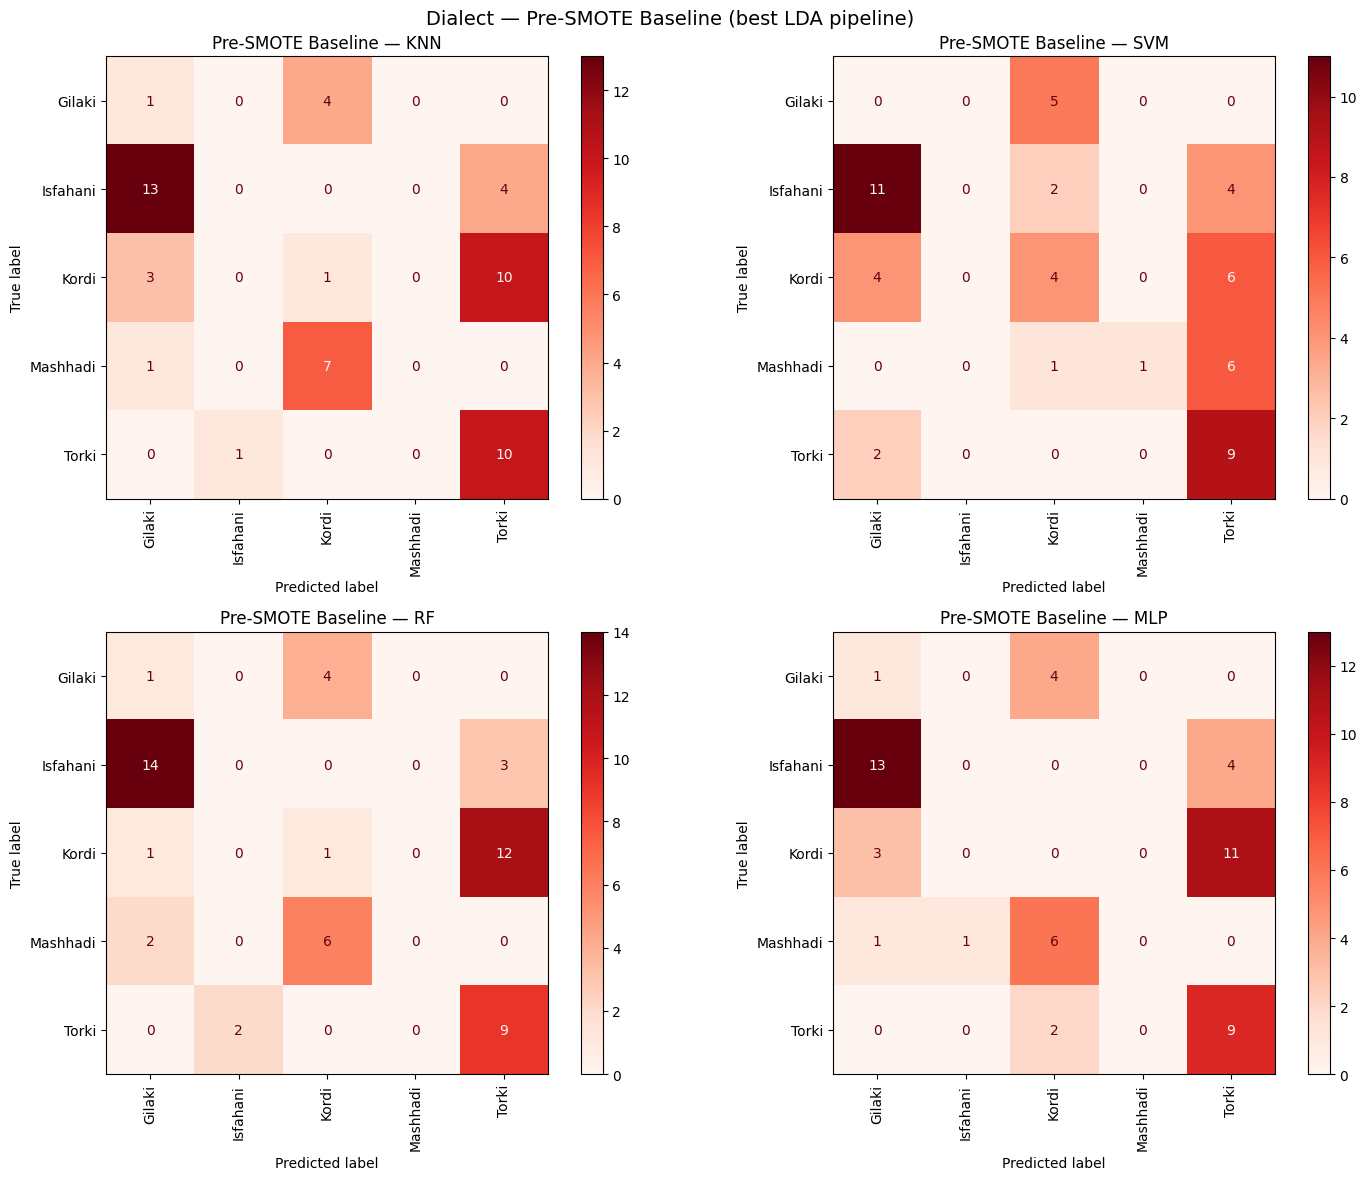

In [ ]:
_p7a = best_svm_dialect_params
_p7b = best_svm_dialect_triple_params

_oof_7a = accuracy_score(
    y_cv_dialect,
    cross_val_predict(
        best_svm_dialect,
        X_cv,
        y_cv_dialect,
        groups=groups_cv,
        cv=StratifiedGroupKFold(n_splits=5),
        n_jobs=2,
    ),
)
_oof_7b = accuracy_score(
    y_cv_dialect,
    cross_val_predict(
        best_svm_dialect_triple,
        X_cv,
        y_cv_dialect,
        groups=groups_cv,
        cv=StratifiedGroupKFold(n_splits=5),
        n_jobs=2,
    ),
)

if _oof_7b >= _oof_7a:
    _best_n_pca = _p7b["feat__pca__n_components"]
    _best_n_anova = _p7b["feat__anova__k"]
    print(
        f"Using TRIPLE branch (7b): n_pca={_best_n_pca}, n_anova={_best_n_anova}  "
        f"(OOF {_oof_7b:.4f} >= {_oof_7a:.4f})"
    )
else:
    _best_n_pca = _p7a["feat__pca__n_components"]
    _best_n_anova = None
    print(
        f"Using 2-branch (7a): n_pca={_best_n_pca}  (OOF {_oof_7a:.4f} > {_oof_7b:.4f})"
    )

print("=" * 60)
print("PRE-SMOTE BASELINE — best LDA pipeline, unbalanced training data")
print(
    f"Feature config: LDA(4) + PCA({_best_n_pca})"
    + (f" + ANOVA({_best_n_anova})" if _best_n_anova else "")
)
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
models = ["knn", "svm", "rf", "mlp"]
trained_pipelines_base = {}

for i, model_type in enumerate(models):
    print(f"\nTraining {model_type.upper()} (no SMOTE)...")
    trained_pipelines_base[model_type] = train_and_evaluate(
        model_type=model_type,
        X_train=X_train_base,  # raw unscaled — pipeline scales internally
        y_train=y_train_base,
        X_val=X_val_final,  # raw unscaled — pipeline scales internally
        y_val=y_val_final,
        ax=axes[i],
        title_prefix="Pre-SMOTE Baseline",
        n_pca=_best_n_pca,
        n_anova=_best_n_anova,
        use_smote=False,
    )

plt.suptitle("Dialect — Pre-SMOTE Baseline (best LDA pipeline)", fontsize=14)
plt.tight_layout()
plt.show()

## Dialect Classification — SMOTE-Balanced Evaluation

This block executes the optimized dialect classification workflow integrated with the Synthetic Minority Over-sampling Technique (SMOTE) to address class distribution skews.

### Execution Details:
* **Imbalance Remediation via `ImbPipeline`**: Leverages an oversampling pipeline to inject synthetic training examples into minority dialect classes dynamically during the training cycle (`use_smote=True`).
* **Validation Separation**: The pipeline architecture ensures that SMOTE resamples only the training data folds. The speaker holdout validation subset (`X_val_final`) is skipped during oversampling, guaranteeing unbiased metric calculations.
* **Comparative Algorithm Evaluation**: Runs training and evaluation scripts across all four primary classification architectures (KNN, SVM, Random Forest, and MLP) under identical structural parameters to isolate the impacts of synthetic balancing.
* **Result Analysis Plots**: Displays the resulting classification breakdowns using a blue-gradient confusion matrix grid (`plt.cm.Blues`) to facilitate a direct side-by-side performance contrast against the previous unbalanced pre-SMOTE run.

SMOTE BALANCED — SMOTE integrated inside ImbPipeline (FIX 2)
Feature config: LDA(4) + PCA(5) + ANOVA(20)

Training KNN (with SMOTE inside pipeline)...

-------------------- SMOTE Balanced — KNN --------------------
              precision    recall  f1-score   support

      Gilaki       0.06      0.20      0.10         5
    Isfahani       0.00      0.00      0.00        17
       Kordi       0.00      0.00      0.00        14
    Mashhadi       0.00      0.00      0.00         8
       Torki       0.35      0.82      0.49        11

    accuracy                           0.18        55
   macro avg       0.08      0.20      0.12        55
weighted avg       0.07      0.18      0.11        55


Training SVM (with SMOTE inside pipeline)...

-------------------- SMOTE Balanced — SVM --------------------
              precision    recall  f1-score   support

      Gilaki       0.19      0.80      0.31         5
    Isfahani       0.00      0.00      0.00        17
       Kordi       0.50

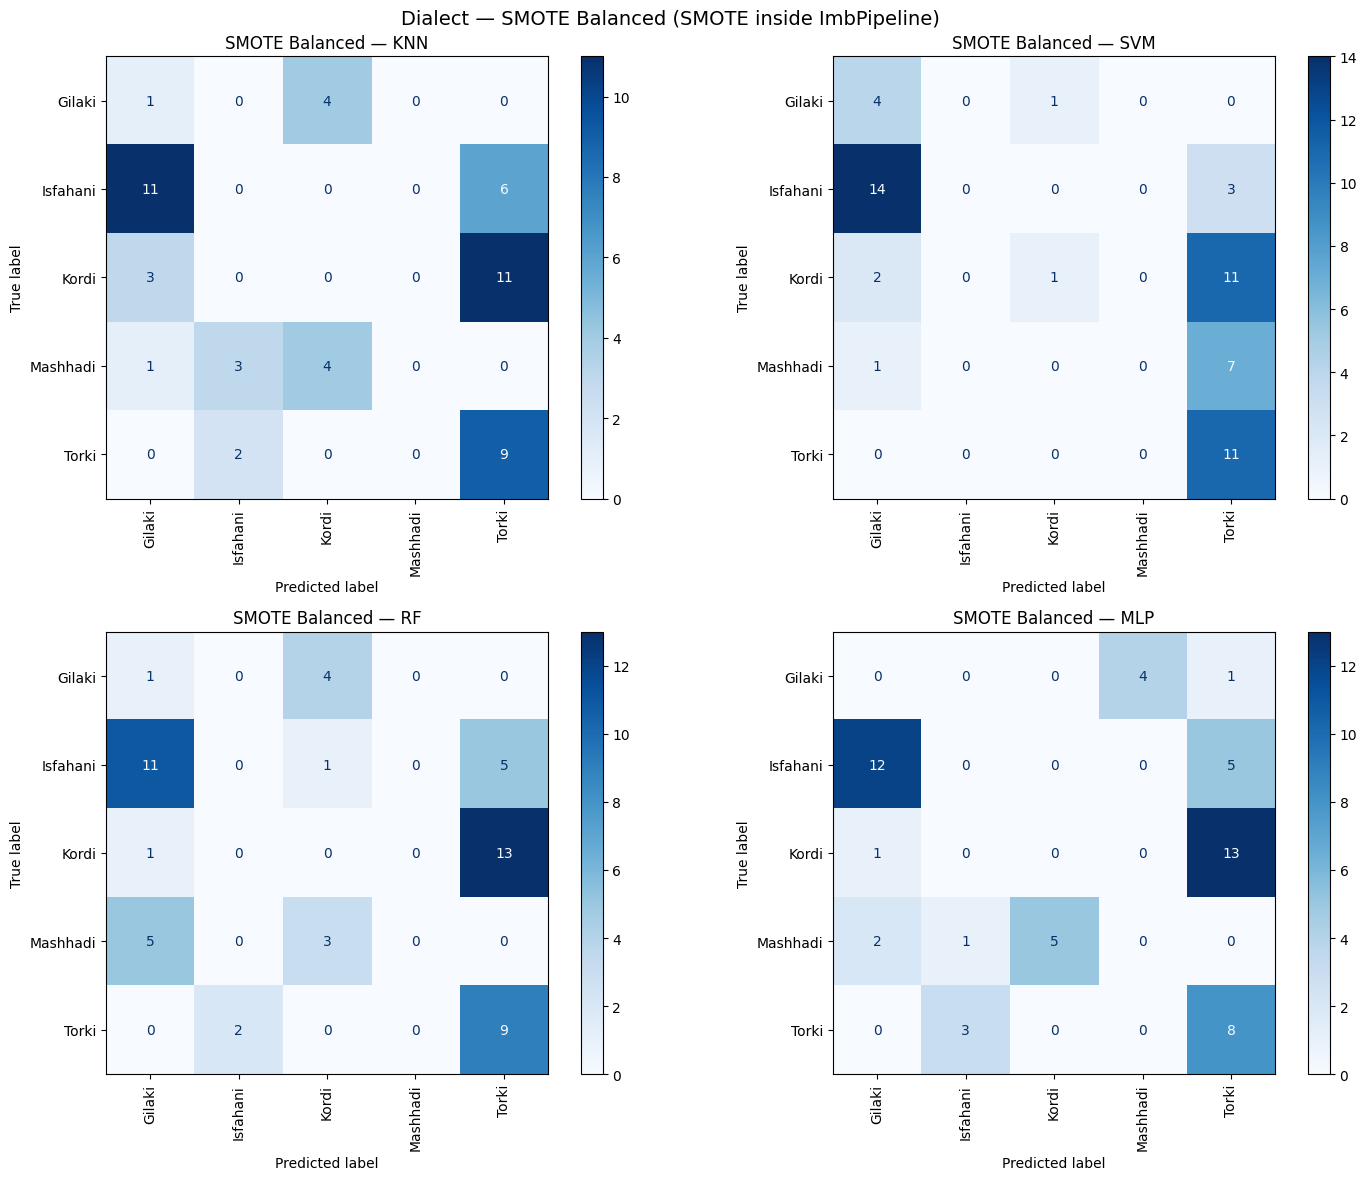

In [ ]:
print("=" * 60)
print("SMOTE BALANCED — SMOTE integrated inside ImbPipeline (FIX 2)")
print(
    f"Feature config: LDA(4) + PCA({_best_n_pca})"
    + (f" + ANOVA({_best_n_anova})" if _best_n_anova else "")
)
print("=" * 60)

fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()
trained_pipelines_smote = {}

for i, model_type in enumerate(models):
    print(f"\nTraining {model_type.upper()} (with SMOTE inside pipeline)...")
    trained_pipelines_smote[model_type] = train_and_evaluate(
        model_type=model_type,
        X_train=X_train_base,  # raw, unbalanced — SMOTE runs inside pipeline
        y_train=y_train_base,
        X_val=X_val_final,  # raw — SMOTE NOT applied during predict()
        y_val=y_val_final,
        ax=axes[i],
        title_prefix="SMOTE Balanced",
        n_pca=_best_n_pca,
        n_anova=_best_n_anova,
        use_smote=True,
    )

plt.suptitle("Dialect — SMOTE Balanced (SMOTE inside ImbPipeline)", fontsize=14)
plt.tight_layout()
plt.show()

## Final Model Evaluation on the Official Test Set

This section executes the final evaluation of the best-performing models on the completely unseen official project test set (`df_test_official`).

### Execution Details:
* **Official Test Processing**: Extracts the independent test feature matrix and segregates the ground-truth targets for both the gender and dialect estimation channels.
* **Inference Execution**:
    * Passes the test features into the optimal gender model pipeline (`best_svm_gender`) to predict speaker gender labels.
    * Passes the test features into the SMOTE-balanced dialect model pipeline (`trained_pipelines_smote['svm']`) to predict regional dialect labels.
* **Performance Analysis**: Computes the official test accuracy alongside detailed classification reports containing precision, recall, and F1-score breakdowns per class.
* **Visual Error Diagnostics**: Draws side-by-side confusion matrices (using a blue color map for gender and a green color map for dialect) to isolate any remaining out-of-distribution classification errors or inter-class confusion patterns.

=== Evaluating SVM — Gender ===
Accuracy: 0.8364

Classification Report:
              precision    recall  f1-score   support

      Female       0.87      0.84      0.85        31
        Male       0.80      0.83      0.82        24

    accuracy                           0.84        55
   macro avg       0.83      0.84      0.83        55
weighted avg       0.84      0.84      0.84        55


=== Evaluating SVM — Dialect ===
Accuracy: 0.4909

Classification Report:
              precision    recall  f1-score   support

      Gilaki       0.50      0.73      0.59        15
    Isfahani       0.20      0.07      0.11        14
       Kordi       0.39      0.70      0.50        10
    Mashhadi       0.00      0.00      0.00         5
       Torki       0.89      0.73      0.80        11

    accuracy                           0.49        55
   macro avg       0.40      0.45      0.40        55
weighted avg       0.44      0.49      0.44        55



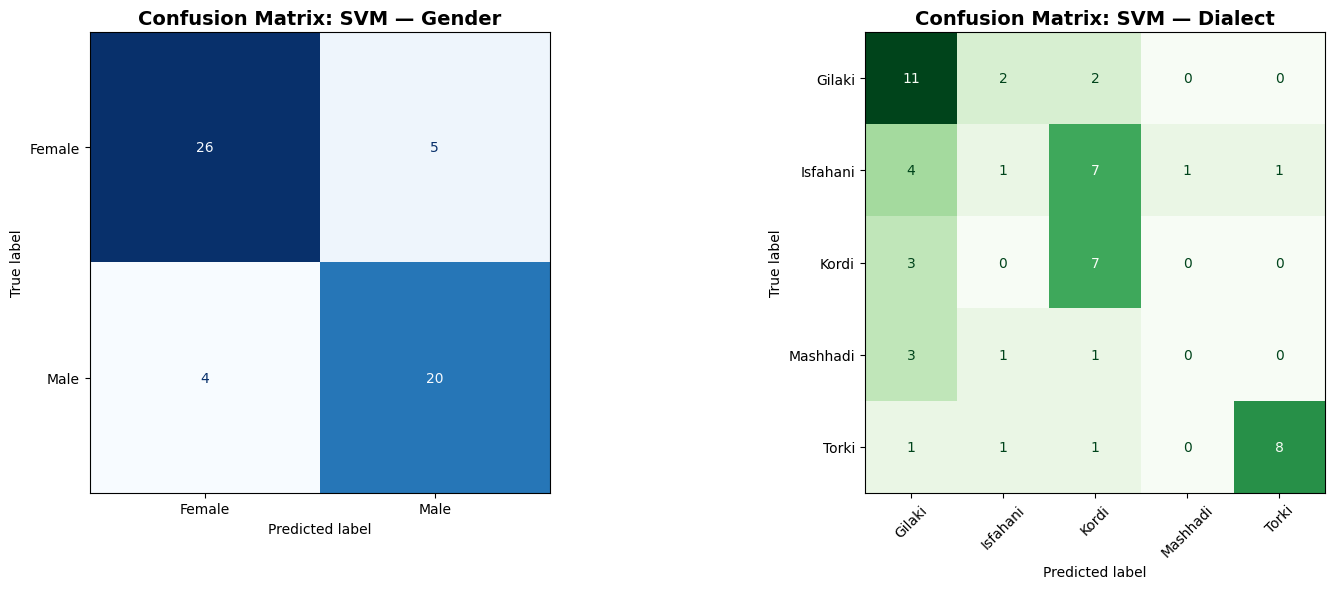

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

X_test = df_test_official.drop(columns=drop_cols)
y_test_gender = df_test_official["gender"]
y_test_dialect = df_test_official["dialect"]


print("=== Evaluating SVM — Gender ===")
# best_svm_gender is a (model, params) tuple
model_gender = best_svm_gender[0]
y_pred_gender = model_gender.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_gender, y_pred_gender):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_gender, y_pred_gender))


print("\n=== Evaluating SVM — Dialect ===")
# We use the trained pipeline from the SMOTE balancing step for the best SVM model
model_dialect = trained_pipelines_smote['svm']
y_pred_dialect = model_dialect.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test_dialect, y_pred_dialect):.4f}")
print("\nClassification Report:")
print(classification_report(y_test_dialect, y_pred_dialect))

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Subplot 1: Gender
cm_gender = confusion_matrix(y_test_gender, y_pred_gender, labels=model_gender.classes_)
disp_gender = ConfusionMatrixDisplay(confusion_matrix=cm_gender, display_labels=model_gender.classes_)
disp_gender.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix: SVM — Gender', fontsize=14, fontweight='bold')

# Subplot 2: Dialect
cm_dialect = confusion_matrix(y_test_dialect, y_pred_dialect, labels=model_dialect.classes_)
disp_dialect = ConfusionMatrixDisplay(confusion_matrix=cm_dialect, display_labels=model_dialect.classes_)
disp_dialect.plot(ax=axes[1], cmap='Greens', colorbar=False, xticks_rotation=45)
axes[1].set_title('Confusion Matrix: SVM — Dialect', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## Ensemble Modeling — Stacking Classifier Development & Test Set Evaluation

This block implements an advanced meta-learning approach by training a `StackingClassifier` to combine the predictions of the top performing triple-branch base models for the dialect classification task.

### Execution Details:
* **Ensemble Architecture**: Aggregates the predictive power of two distinct foundational architectures:
    * The optimal triple-branch Support Vector Machine (`best_svm_dialect_triple`).
    * The optimal triple-branch Multi-Layer Perceptron (`best_mlp_dialect_triple`).
* **Meta-Classifier Blending**: Configures a `LogisticRegression` meta-learner with balanced class weights to process the out-of-fold prediction probabilities generated by the base estimators. It uses an internal 5-fold cross-validation scheme to prevent meta-level data leakage.
* **Official Test Set Inference**: Executes the final evaluation by passing the independent official test features (`X_test`) into the fitted stack ensemble to capture dialect labels.
* **Performance Metric Output**: Calculates overall ensemble accuracy alongside a comprehensive precision, recall, and F1-score classification report to analyze the impact of stacking.
* **Error Visualization**: Draws a dedicated purple-gradient confusion matrix to map out the ensemble's classification boundaries and misclassification patterns across dialect groups.

TRAINING STACKING CLASSIFIER: SVM + MLP (TRIPLE PIPELINE)
Training complete.

EVALUATING STACKING CLASSIFIER ON OFFICIAL TEST SET
Stacking Model Accuracy: 0.6545

Classification Report:
              precision    recall  f1-score   support

      Gilaki       0.75      0.60      0.67        15
    Isfahani       0.80      0.57      0.67        14
       Kordi       0.39      0.70      0.50        10
    Mashhadi       1.00      0.40      0.57         5
       Torki       0.77      0.91      0.83        11

    accuracy                           0.65        55
   macro avg       0.74      0.64      0.65        55
weighted avg       0.72      0.65      0.66        55



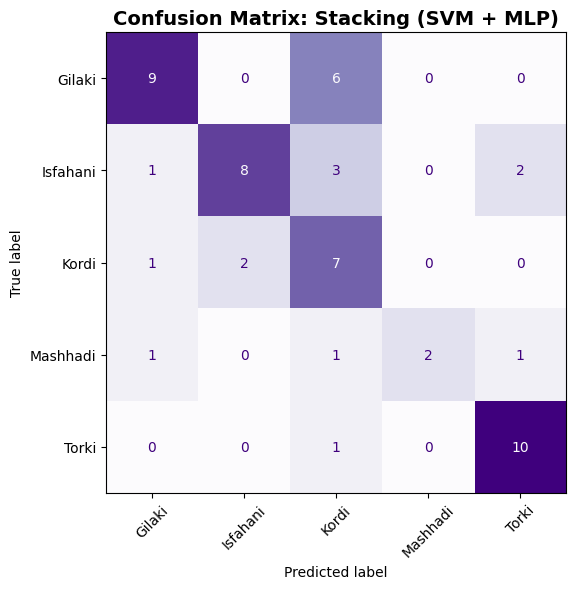

In [ ]:
import matplotlib.pyplot as plt
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

print("=" * 60)
print("TRAINING STACKING CLASSIFIER: SVM + MLP (TRIPLE PIPELINE)")
print("=" * 60)

# Extract the fitted models from your previous variables.
# StackingClassifier will clone these and their pipeline steps.
estimators = [
    ('svm_triple', best_svm_dialect_triple),
    ('mlp_triple', best_mlp_dialect_triple)
]

# Initialize Stacking with Logistic Regression as the final estimator
stack_clf = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    cv=5,      # 5-fold CV to generate meta-features for the meta-classifier
    n_jobs=-1  # Use all available cores
)

# Fit the stack on the training/cv data
stack_clf.fit(X_cv, y_cv_dialect)
print("Training complete.\n")

print("=" * 60)
print("EVALUATING STACKING CLASSIFIER ON OFFICIAL TEST SET")
print("=" * 60)

# Predict on the isolated test set from Part 1
y_pred_stack = stack_clf.predict(X_test)

# Print Metrics
acc_stack = accuracy_score(y_test_dialect, y_pred_stack)
print(f"Stacking Model Accuracy: {acc_stack:.4f}\n")
print("Classification Report:")
print(classification_report(y_test_dialect, y_pred_stack))


fig, ax = plt.subplots(figsize=(8, 6))

cm_stack = confusion_matrix(y_test_dialect, y_pred_stack, labels=stack_clf.classes_)
disp_stack = ConfusionMatrixDisplay(confusion_matrix=cm_stack, display_labels=stack_clf.classes_)

# Using 'Purples' to visually distinguish the Stacking model from your earlier SVM models
disp_stack.plot(ax=ax, cmap='Purples', colorbar=False, xticks_rotation=45)
ax.set_title('Confusion Matrix: Stacking (SVM + MLP)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

## **Part 2 — Dialect Clustering**

 **Goal:** Explore whether speech samples naturally separate by dialect
 without using any labels.

 **Algorithms covered:**
 - K-Means
 - Gaussian Mixture Model (GMM)
 - DBSCAN
 - Hierarchical Clustering

 **Variables inherited from Part 1:**
 | Variable | Description |
 |---|---|
 | `X_train_base` | Raw (unscaled) feature matrix — train split |
 | `y_train_base` | Dialect labels — train split |
 | `X_cv` | Raw features — all non-test samples |
 | `y_cv_dialect` | Dialect labels — all non-test samples |



In [ ]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from sklearn.cluster import DBSCAN, KMeans
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    silhouette_score,
)
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")


## **0 — Data Preparation**

 Clustering is performed on the **train split only** (same boundary as classification).
 The `StandardScaler` is **fit on train data only** — applying it to validation or
 test data afterwards prevents any data leakage.


In [ ]:
scaler_clust = StandardScaler()
X_train_scaled = scaler_clust.fit_transform(X_train_base)

true_labels = y_train_base.values
n_true_dialects = len(np.unique(true_labels))

print("=" * 60)
print("CLUSTERING SETUP")
print("=" * 60)
print(f"Training samples      : {X_train_scaled.shape[0]}")
print(f"Features              : {X_train_scaled.shape[1]}")
print(f"True dialect classes  : {n_true_dialects}")
print(f"Dialect names         : {sorted(np.unique(true_labels))}")

CLUSTERING SETUP
Training samples      : 269
Features              : 99
True dialect classes  : 5
Dialect names         : ['Gilaki', 'Isfahani', 'Kordi', 'Mashhadi', 'Torki']


## **1 — K-Means**

 We sweep `k` from 2 to 11 and use two criteria to pick the optimal number
 of clusters:
 - **Elbow Method** — look for the kink in the inertia curve
 - **Silhouette Score** — higher is better; peak indicates the best k

 The red dashed line marks the **true number of dialects** as a reference.

  k= 2  Inertia=22222.9  Silhouette=0.1674
  k= 3  Inertia=19916.3  Silhouette=0.1480
  k= 4  Inertia=18304.2  Silhouette=0.1645
  k= 5  Inertia=17092.7  Silhouette=0.1724
  k= 6  Inertia=15992.7  Silhouette=0.1689
  k= 7  Inertia=14997.3  Silhouette=0.1862
  k= 8  Inertia=14244.6  Silhouette=0.1940
  k= 9  Inertia=13812.0  Silhouette=0.1894
  k=10  Inertia=12837.8  Silhouette=0.2125
  k=11  Inertia=12164.6  Silhouette=0.2238


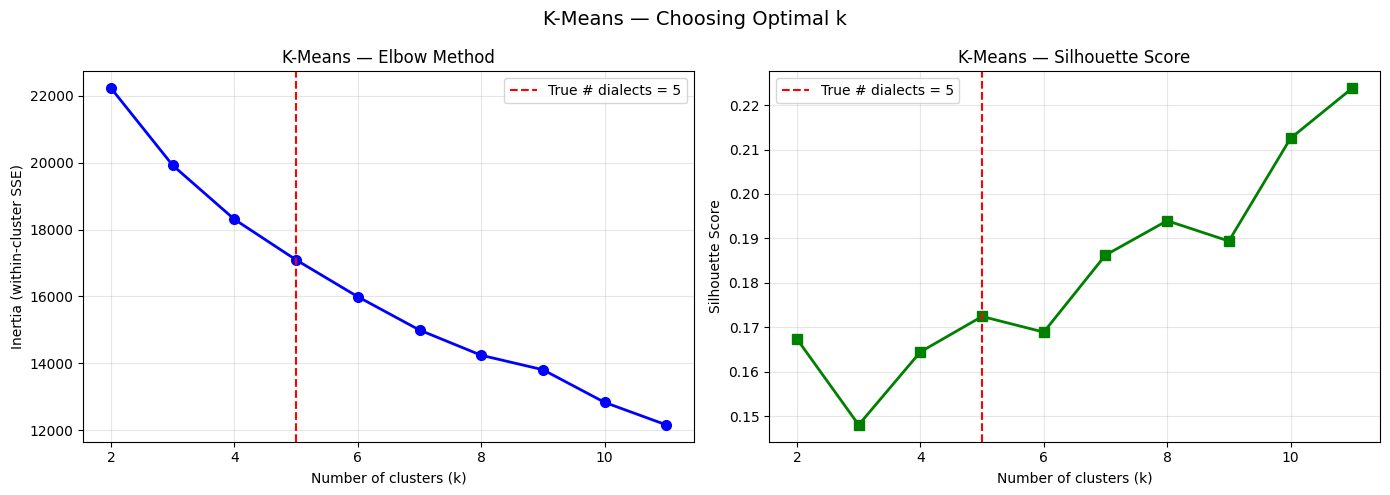


K-Means (k=5):
  Silhouette Score : 0.1724
  NMI              : 0.3029
  ARI              : 0.1561

Cluster composition (K-Means, k=5):
dialect  Gilaki  Isfahani  Kordi  Mashhadi  Torki
cluster                                          
0             1        16      0         0      0
1             0         0     18         0     22
2            33         0      0         0     20
3             6         1     42        12     31
4            30         8     15         1     13


In [ ]:
k_range = range(2, 12)
inertias = []
silhouette_scores_km = []

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_km = km.fit_predict(X_train_scaled)
    inertias.append(km.inertia_)
    sil = silhouette_score(X_train_scaled, labels_km)
    silhouette_scores_km.append(sil)
    print(f"  k={k:2d}  Inertia={km.inertia_:.1f}  Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(k_range), inertias, "bo-", linewidth=2, markersize=7)
axes[0].axvline(x=n_true_dialects, color="red", linestyle="--",
                label=f"True # dialects = {n_true_dialects}")
axes[0].set_xlabel("Number of clusters (k)")
axes[0].set_ylabel("Inertia (within-cluster SSE)")
axes[0].set_title("K-Means — Elbow Method")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(k_range), silhouette_scores_km, "gs-", linewidth=2, markersize=7)
axes[1].axvline(x=n_true_dialects, color="red", linestyle="--",
                label=f"True # dialects = {n_true_dialects}")
axes[1].set_xlabel("Number of clusters (k)")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("K-Means — Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("K-Means — Choosing Optimal k", fontsize=14)
plt.tight_layout()
plt.show()

# Train final K-Means with k equal to the true number of dialects
km_best = KMeans(n_clusters=n_true_dialects, random_state=42, n_init=10)
km_labels = km_best.fit_predict(X_train_scaled)

sil_km = silhouette_score(X_train_scaled, km_labels)
nmi_km = normalized_mutual_info_score(true_labels, km_labels)
ari_km = adjusted_rand_score(true_labels, km_labels)

print(f"\nK-Means (k={n_true_dialects}):")
print(f"  Silhouette Score : {sil_km:.4f}")
print(f"  NMI              : {nmi_km:.4f}")
print(f"  ARI              : {ari_km:.4f}")

# Show the true-label composition of each cluster
print(f"\nCluster composition (K-Means, k={n_true_dialects}):")
km_df = pd.DataFrame({"cluster": km_labels, "dialect": true_labels})
print(km_df.groupby("cluster")["dialect"].value_counts().unstack(fill_value=0))

## **2 — Gaussian Mixture Model (GMM)**

 GMM is a soft-assignment clustering method that models each cluster as a
 Gaussian distribution. We select the number of components using:
 - **BIC / AIC** — lower is better; the minimum suggests the best n
 - **Silhouette Score** — as a secondary sanity check


  n= 2  BIC=40376.7  AIC=4073.7  Silhouette=0.1713
  n= 3  BIC=28862.6  AIC=-25593.7  Silhouette=0.1412
  n= 4  BIC=22177.5  AIC=-50432.1  Silhouette=0.1374
  n= 5  BIC=9890.5  AIC=-80872.4  Silhouette=0.1554
  n= 6  BIC=27988.9  AIC=-80927.3  Silhouette=0.1643
  n= 7  BIC=31850.4  AIC=-95219.0  Silhouette=0.1595
  n= 8  BIC=37609.5  AIC=-107613.3  Silhouette=0.1940
  n= 9  BIC=60654.8  AIC=-102721.2  Silhouette=0.1871
  n=10  BIC=84377.1  AIC=-97152.2  Silhouette=0.2125
  n=11  BIC=90478.7  AIC=-109203.9  Silhouette=0.2193


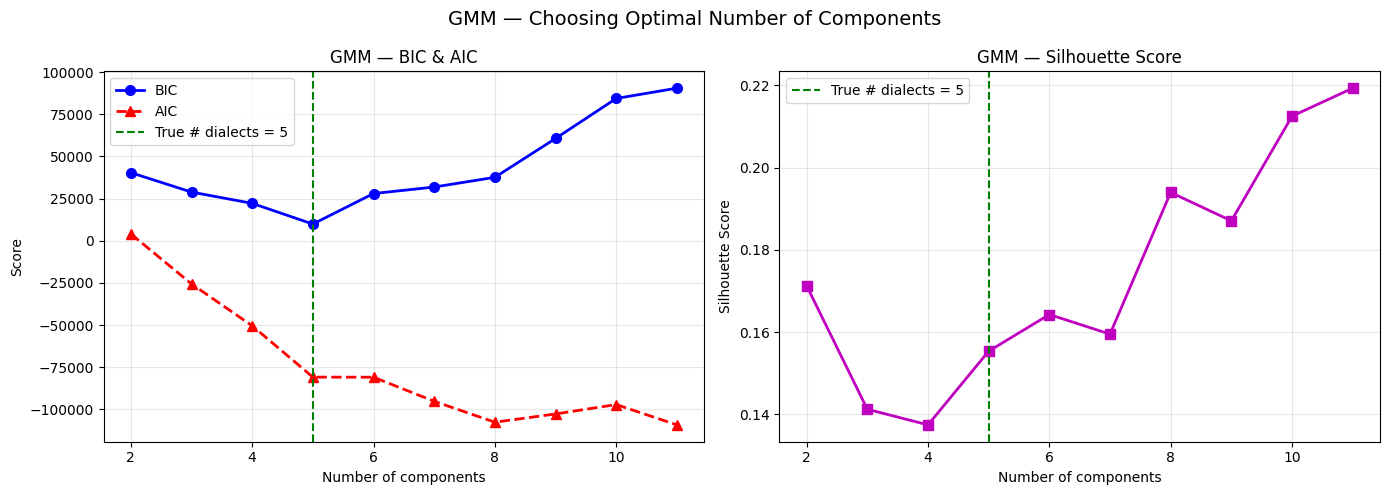


GMM (n_components=5):
  Silhouette Score : 0.1554
  NMI              : 0.3048
  ARI              : 0.1679

Cluster composition (GMM, n=5):
dialect  Gilaki  Isfahani  Kordi  Mashhadi  Torki
cluster                                          
0            27        20      0         0     12
1             0         0     18         0     22
2             1         0     23         1     19
3            36         3      0         0     20
4             6         2     34        12     13


In [ ]:
bic_scores = []
aic_scores = []
silhouette_scores_gmm = []
n_components_range = range(2, 12)

for n in n_components_range:
    gmm = GaussianMixture(n_components=n, random_state=42, n_init=3)
    gmm.fit(X_train_scaled)
    labels_gmm = gmm.predict(X_train_scaled)
    bic_scores.append(gmm.bic(X_train_scaled))
    aic_scores.append(gmm.aic(X_train_scaled))
    sil = silhouette_score(X_train_scaled, labels_gmm)
    silhouette_scores_gmm.append(sil)
    print(f"  n={n:2d}  BIC={gmm.bic(X_train_scaled):.1f}  "
          f"AIC={gmm.aic(X_train_scaled):.1f}  Silhouette={sil:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(n_components_range), bic_scores, "bo-", linewidth=2,
             markersize=7, label="BIC")
axes[0].plot(list(n_components_range), aic_scores, "r^--", linewidth=2,
             markersize=7, label="AIC")
axes[0].axvline(x=n_true_dialects, color="green", linestyle="--",
                label=f"True # dialects = {n_true_dialects}")
axes[0].set_xlabel("Number of components")
axes[0].set_ylabel("Score")
axes[0].set_title("GMM — BIC & AIC")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(n_components_range), silhouette_scores_gmm, "ms-",
             linewidth=2, markersize=7)
axes[1].axvline(x=n_true_dialects, color="green", linestyle="--",
                label=f"True # dialects = {n_true_dialects}")
axes[1].set_xlabel("Number of components")
axes[1].set_ylabel("Silhouette Score")
axes[1].set_title("GMM — Silhouette Score")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle("GMM — Choosing Optimal Number of Components", fontsize=14)
plt.tight_layout()
plt.show()

# Train final GMM with the true number of dialects
gmm_best = GaussianMixture(n_components=n_true_dialects, random_state=42, n_init=5)
gmm_best.fit(X_train_scaled)
gmm_labels = gmm_best.predict(X_train_scaled)

sil_gmm = silhouette_score(X_train_scaled, gmm_labels)
nmi_gmm = normalized_mutual_info_score(true_labels, gmm_labels)
ari_gmm = adjusted_rand_score(true_labels, gmm_labels)

print(f"\nGMM (n_components={n_true_dialects}):")
print(f"  Silhouette Score : {sil_gmm:.4f}")
print(f"  NMI              : {nmi_gmm:.4f}")
print(f"  ARI              : {ari_gmm:.4f}")

print(f"\nCluster composition (GMM, n={n_true_dialects}):")
gmm_df = pd.DataFrame({"cluster": gmm_labels, "dialect": true_labels})
print(gmm_df.groupby("cluster")["dialect"].value_counts().unstack(fill_value=0))


## **3 — DBSCAN**

 DBSCAN is a density-based algorithm that does **not** require specifying the
 number of clusters upfront. Points in low-density regions are labelled as
 **noise (−1)**.

 **Hyperparameter selection strategy:**
 1. Plot the **k-distance curve** to visually identify a reasonable `eps`
    (the elbow of the curve is a good starting point).
 2. Run a **grid search** over `eps × min_samples` and pick the combination
    with the highest NMI (the league metric).


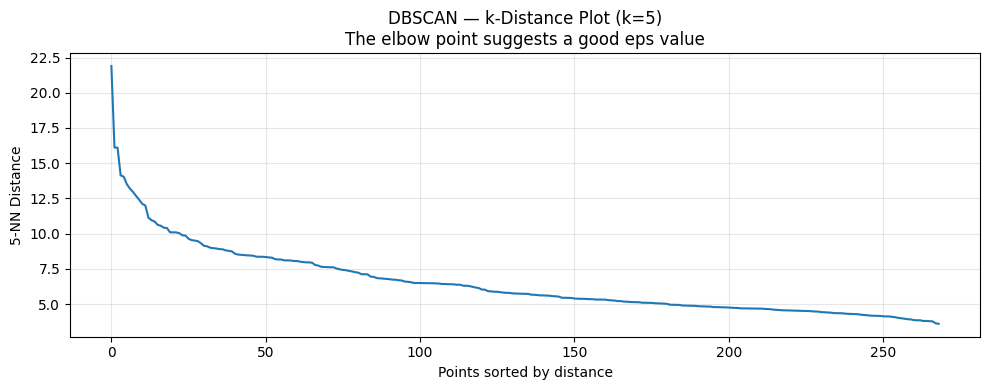

Adaptive eps range (from k-distance percentiles): [4.28, 4.61, 4.88, 5.29, 5.73, 6.43, 7.19, 8.18, 9.52]

DBSCAN grid search (eps x min_samples):
  eps=4.28  min_samples= 3  clusters=16  noise=167 (62.1%)  Silhouette=-0.069  NMI=0.3598
  eps=4.28  min_samples= 5  clusters= 7  noise=207 (77.0%)  Silhouette=-0.079  NMI=0.2911
  eps=4.28  min_samples= 7  clusters= 2  noise=245 (91.1%)  Silhouette=-0.036  NMI=0.1399
  eps=4.61  min_samples= 3  clusters=17  noise=137 (50.9%)  Silhouette=0.042  NMI=0.4226
  eps=4.61  min_samples= 5  clusters=10  noise=166 (61.7%)  Silhouette=0.010  NMI=0.3772
  eps=4.61  min_samples= 7  clusters= 7  noise=200 (74.3%)  Silhouette=-0.070  NMI=0.3127
  eps=4.61  min_samples=10  clusters= 2  noise=244 (90.7%)  Silhouette=-0.033  NMI=0.1456
  eps=4.88  min_samples= 3  clusters=20  noise=110 (40.9%)  Silhouette=0.106  NMI=0.4581
  eps=4.88  min_samples= 5  clusters=12  noise=144 (53.5%)  Silhouette=0.045  NMI=0.4178
  eps=4.88  min_samples= 7  clusters= 9  noise=1

In [ ]:
from sklearn.neighbors import NearestNeighbors

k_nn  = 5
nbrs  = NearestNeighbors(n_neighbors=k_nn).fit(X_train_scaled)
distances, _ = nbrs.kneighbors(X_train_scaled)
k_distances  = np.sort(distances[:, -1])[::-1]

plt.figure(figsize=(10, 4))
plt.plot(k_distances, linewidth=1.5)
plt.xlabel("Points sorted by distance")
plt.ylabel(f"{k_nn}-NN Distance")
plt.title(f"DBSCAN — k-Distance Plot (k={k_nn})\n"
          "The elbow point suggests a good eps value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# %%
# Build an adaptive eps range from the actual k-distance distribution
percentiles    = [10, 20, 30, 40, 50, 60, 70, 80, 90]
eps_candidates = sorted(set(
    round(float(np.percentile(k_distances, p)), 2) for p in percentiles
))
min_samples_candidates = [3, 5, 7, 10]

print(f"Adaptive eps range (from k-distance percentiles): {eps_candidates}\n")
print("DBSCAN grid search (eps x min_samples):")

best_dbscan_nmi    = -1
best_dbscan_params = {}
best_dbscan_labels = None

for eps in eps_candidates:
    for ms in min_samples_candidates:
        db        = DBSCAN(eps=eps, min_samples=ms)
        db_labels = db.fit_predict(X_train_scaled)
        n_clusters = len(set(db_labels)) - (1 if -1 in db_labels else 0)
        n_noise    = (db_labels == -1).sum()
        noise_pct  = n_noise / len(db_labels) * 100

        if n_clusters < 2:
            continue

        sil = silhouette_score(X_train_scaled, db_labels)
        nmi = normalized_mutual_info_score(true_labels, db_labels)

        print(f"  eps={eps:.2f}  min_samples={ms:2d}  "
              f"clusters={n_clusters:2d}  noise={n_noise:3d} ({noise_pct:.1f}%)  "
              f"Silhouette={sil:.3f}  NMI={nmi:.4f}")

        if nmi > best_dbscan_nmi:
            best_dbscan_nmi    = nmi
            best_dbscan_params = {"eps": eps, "min_samples": ms}
            best_dbscan_labels = db_labels

# If DBSCAN still found no valid partition, fall back to K-Means labels
if best_dbscan_labels is None:
    print("\nDBSCAN could not find a valid partition for any (eps, min_samples).")
    print("Falling back to K-Means labels for downstream plots.")
    best_dbscan_labels = km_labels
    best_dbscan_params = {"fallback": "K-Means"}
    n_clust_db         = n_true_dialects
    best_dbscan_nmi    = nmi_km
else:
    n_clust_db = len(set(best_dbscan_labels)) - (1 if -1 in best_dbscan_labels else 0)

# %%
print(f"\nBest DBSCAN params  : {best_dbscan_params}")
n_noise_db = (np.array(best_dbscan_labels) == -1).sum()
print(f"Number of clusters  : {n_clust_db}")
print(f"Noise points        : {n_noise_db} ({n_noise_db/len(best_dbscan_labels)*100:.1f}%)")
print(f"NMI                 : {best_dbscan_nmi:.4f}")

if n_clust_db >= 2:
    sil_db = silhouette_score(X_train_scaled, best_dbscan_labels)
    ari_db = adjusted_rand_score(true_labels, best_dbscan_labels)
    print(f"Silhouette Score    : {sil_db:.4f}")
    print(f"ARI                 : {ari_db:.4f}")

print(f"\nCluster composition (DBSCAN / fallback):")
db_df = pd.DataFrame({"cluster": best_dbscan_labels, "dialect": true_labels})
print(db_df.groupby("cluster")["dialect"].value_counts().unstack(fill_value=0))


 ## **4 — Hierarchical Clustering**

 We compare three linkage strategies — **ward**, **complete**, and **average** —
 using dendrograms (on a 200-sample subset for readability) and then evaluate
 all three on the full training set.

 The **red dashed line** on each dendrogram marks the cut height that yields
 exactly `n_true_dialects` clusters.


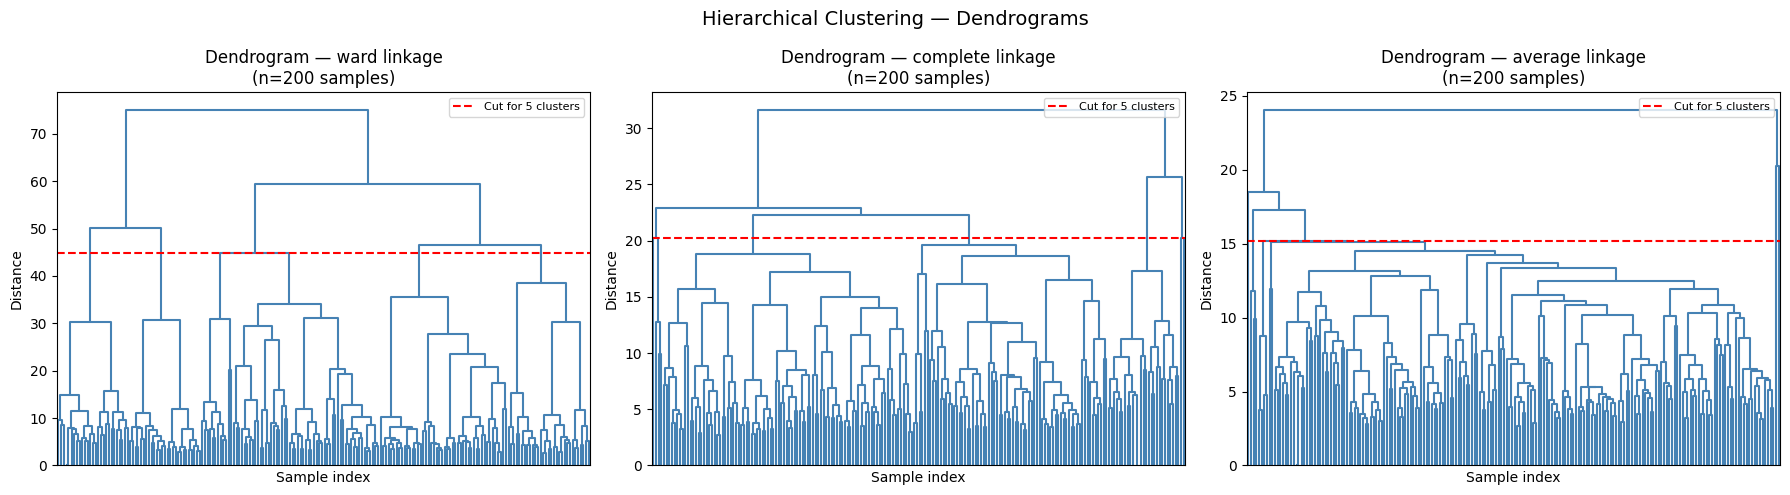

Hierarchical Clustering — linkage comparison:
  ward      Silhouette=0.1700  NMI=0.2900  ARI=0.1376
  complete  Silhouette=0.1135  NMI=0.1856  ARI=0.0863
  average   Silhouette=0.2232  NMI=0.0500  ARI=0.0139

Best linkage method : ward  (NMI=0.2900)

Cluster composition (Hierarchical — ward):
dialect  Gilaki  Isfahani  Kordi  Mashhadi  Torki
cluster                                          
0             0         0     17         0     20
1            29         0      0         0     20
2             9         1     44        13     32
3             1        15      0         0      0
4            31         9     14         0     14


In [ ]:
# Dendrogram on a random subset for readability
sample_size = min(200, X_train_scaled.shape[0])
rng = np.random.default_rng(42)
sample_idx = rng.choice(X_train_scaled.shape[0], sample_size, replace=False)
X_sample = X_train_scaled[sample_idx]

linkage_methods = ["ward", "complete", "average"]
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, method in zip(axes, linkage_methods):
    Z = linkage(X_sample, method=method)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=0,
               above_threshold_color="steelblue")
    ax.set_title(f"Dendrogram — {method} linkage\n(n={sample_size} samples)")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Distance")
    ax.axhline(y=Z[-n_true_dialects, 2], color="red", linestyle="--",
               label=f"Cut for {n_true_dialects} clusters")
    ax.legend(fontsize=8)

plt.suptitle("Hierarchical Clustering — Dendrograms", fontsize=14)
plt.tight_layout()
plt.show()

# Compare linkage methods on the full training data
print("Hierarchical Clustering — linkage comparison:")
best_hier_nmi = -1
best_hier_method = ""
best_hier_labels = None

for method in linkage_methods:
    Z_full = linkage(X_train_scaled, method=method)
    hier_labels = fcluster(Z_full, t=n_true_dialects, criterion="maxclust") - 1

    sil_h = silhouette_score(X_train_scaled, hier_labels)
    nmi_h = normalized_mutual_info_score(true_labels, hier_labels)
    ari_h = adjusted_rand_score(true_labels, hier_labels)

    print(f"  {method:8s}  Silhouette={sil_h:.4f}  NMI={nmi_h:.4f}  ARI={ari_h:.4f}")

    if nmi_h > best_hier_nmi:
        best_hier_nmi = nmi_h
        best_hier_method = method
        best_hier_labels = hier_labels

print(f"\nBest linkage method : {best_hier_method}  (NMI={best_hier_nmi:.4f})")
print(f"\nCluster composition (Hierarchical — {best_hier_method}):")
hier_df = pd.DataFrame({"cluster": best_hier_labels, "dialect": true_labels})
print(hier_df.groupby("cluster")["dialect"].value_counts().unstack(fill_value=0))

## **5 — Algorithm Comparison**

 All four algorithms are ranked by **NMI** (the Clustering League metric),
 **Silhouette Score**, and **ARI**.

 > **Note:** DBSCAN is included only if it produced ≥ 2 non-noise clusters.


In [ ]:
summary_rows = [
    ("K-Means",      km_labels,        sil_km,  nmi_km,  ari_km),
    ("GMM",          gmm_labels,       sil_gmm, nmi_gmm, ari_gmm),
    ("Hierarchical", best_hier_labels,
     silhouette_score(X_train_scaled, best_hier_labels),
     best_hier_nmi,
     adjusted_rand_score(true_labels, best_hier_labels)),
]

# Include DBSCAN only if it produced at least 2 clusters
if n_clust_db >= 2:
    summary_rows.append((
        "DBSCAN",
        best_dbscan_labels,
        silhouette_score(X_train_scaled, best_dbscan_labels),
        best_dbscan_nmi,
        adjusted_rand_score(true_labels, best_dbscan_labels),
    ))

summary_df = pd.DataFrame(
    [(name, f"{sil:.4f}", f"{nmi:.4f}", f"{ari:.4f}")
     for name, _, sil, nmi, ari in summary_rows],
    columns=["Algorithm", "Silhouette ↑", "NMI ↑", "ARI ↑"]
)
print(summary_df.to_string(index=False))

# Pick the best algorithm based on NMI (the league evaluation metric)
best_algo_name, best_algo_labels, _, best_algo_nmi, _ = max(
    summary_rows, key=lambda x: x[3]
)
print(f"\nBest algorithm for league (NMI): {best_algo_name}  (NMI={best_algo_nmi:.4f})")

   Algorithm Silhouette ↑  NMI ↑  ARI ↑
     K-Means       0.1724 0.3029 0.1561
         GMM       0.1554 0.3048 0.1679
Hierarchical       0.1700 0.2900 0.1376
      DBSCAN       0.1983 0.5176 0.1773

Best algorithm for league (NMI): DBSCAN  (NMI=0.5176)


## **5b — Evaluation Dashboard**

Comprehensive quality check for all clustering algorithms.
Add this cell right after the summary_df print in Section 5.

Checks:
- NMI ranking (league metric)
- Silhouette scores
- ARI scores
- DBSCAN noise ratio
- Cluster size balance
- Cluster purity (dominant dialect per cluster)
- Stability check (K-Means vs GMM agreement)


CLUSTERING EVALUATION DASHBOARD
                 NMI  Silhouette     ARI  Purity  Noise %  # Clusters  Balance
Algorithm                                                                     
K-Means       0.3029      0.1724  0.1561  0.6036   0.0000           5   0.1848
GMM           0.3048      0.1554  0.1679  0.5296   0.0000           5   0.5970
Hierarchical  0.2900      0.1700  0.1376  0.5940   0.0000           5   0.1616
DBSCAN        0.5176      0.1983  0.1773  0.9739  23.4201          18   0.0882

★  Best algorithm (NMI — league metric): DBSCAN  (NMI = 0.5176)

── Checklist ──────────────────────────────────────────────────
  ✔  NMI strong  (0.518 ≥ 0.50)  →  clusters align well with true dialects
  ⚠  Silhouette low (0.198)  →  high overlap between clusters
  ✔  Cluster purity good (0.974)
  ⚠  Imbalanced clusters (0.09)  →  one cluster dominates
  ⚠  DBSCAN noise moderate (23.4%)
  ✔  K-Means ≈ GMM  (Δ=0.002)  →  results are stable
  ⚠  Cluster count mismatch: found 18, expected

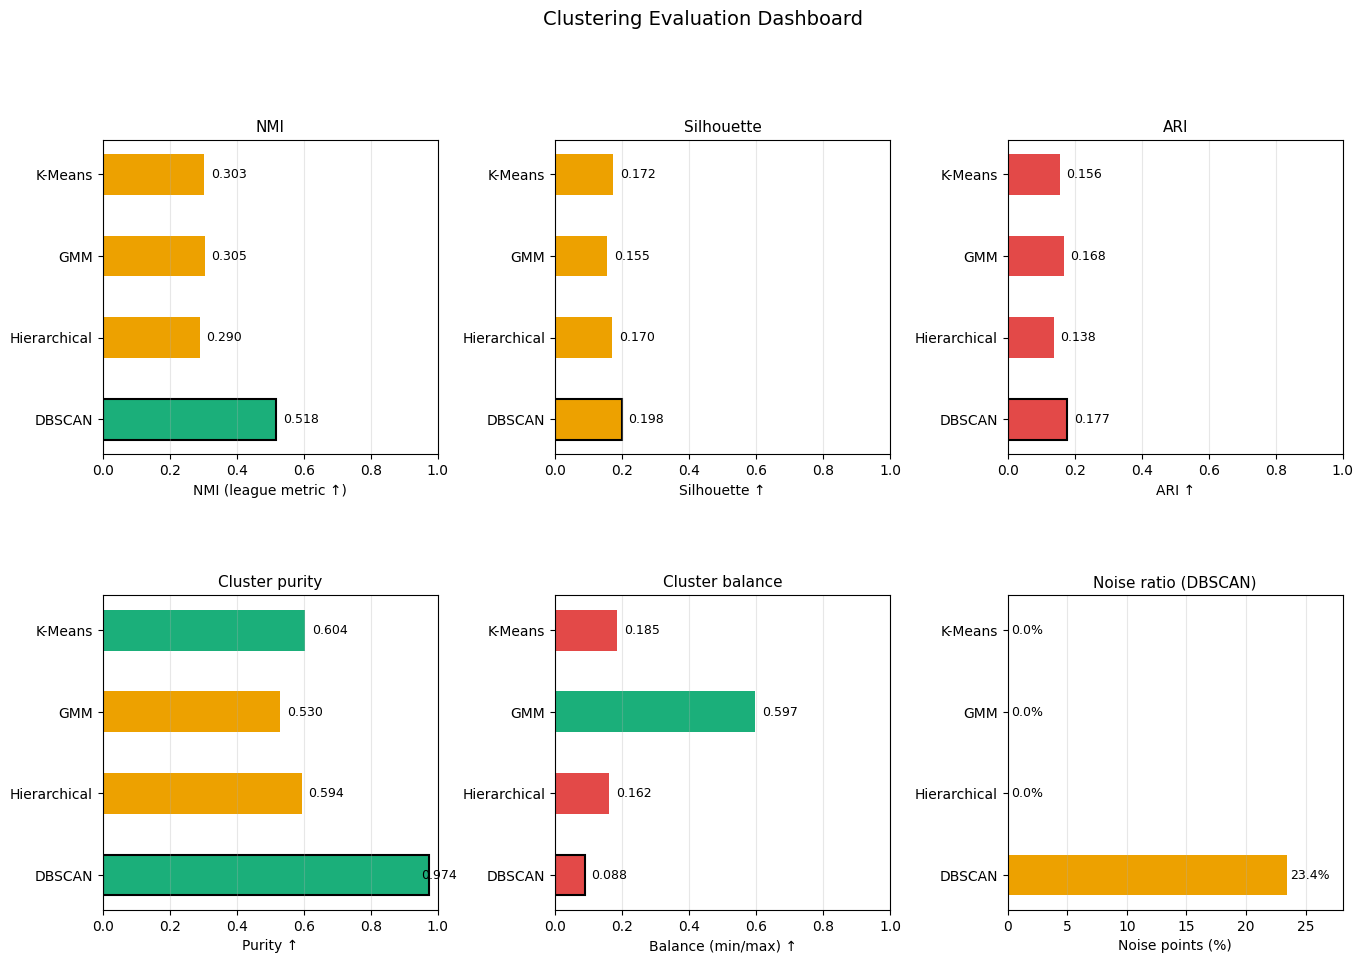


Evaluation complete. Best model → DBSCAN  (NMI = 0.5176)


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from collections import Counter
from sklearn.metrics import silhouette_score, adjusted_rand_score

# ── helpers ──────────────────────────────────────────────────────────────────

def cluster_purity(labels, true_labels):
    """Average fraction of the dominant class in each cluster."""
    scores = []
    for cid in np.unique(labels):
        if cid == -1:
            continue
        mask = labels == cid
        cluster_true = true_labels[mask]
        _, counts = np.unique(cluster_true, return_counts=True)
        scores.append(counts.max() / mask.sum())
    return float(np.mean(scores)) if scores else 0.0


def noise_ratio(labels):
    """Fraction of points labelled as noise (-1) by DBSCAN."""
    return (np.array(labels) == -1).mean()


# ── collect metrics for every algorithm ──────────────────────────────────────

true_labels_arr = np.array(true_labels)   # make sure it's a numpy array

eval_rows = []
for name, labels, sil, nmi, ari in summary_rows:
    labels_arr = np.array(labels)
    nr   = noise_ratio(labels_arr)
    pur  = cluster_purity(labels_arr, true_labels_arr)
    sizes = Counter(l for l in labels_arr if l != -1)
    n_clusters = len(sizes)
    balance = min(sizes.values()) / max(sizes.values()) if sizes else 0.0
    eval_rows.append({
        "Algorithm" : name,
        "NMI"       : nmi,
        "Silhouette": sil,
        "ARI"       : ari,
        "Purity"    : pur,
        "Noise %"   : nr * 100,
        "# Clusters": n_clusters,
        "Balance"   : balance,   # min_cluster / max_cluster  (1 = perfectly balanced)
    })

eval_df = pd.DataFrame(eval_rows).set_index("Algorithm")

# ── console summary ───────────────────────────────────────────────────────────

print("\n" + "=" * 65)
print("CLUSTERING EVALUATION DASHBOARD")
print("=" * 65)
print(eval_df.round(4).to_string())

winner = eval_df["NMI"].idxmax()
print(f"\n★  Best algorithm (NMI — league metric): {winner}  "
      f"(NMI = {eval_df.loc[winner, 'NMI']:.4f})")

# ── checklist ────────────────────────────────────────────────────────────────

def check(ok, label, detail=""):
    sym = "✔" if ok is True else ("✘" if ok is False else "⚠")
    print(f"  {sym}  {label}" + (f"  →  {detail}" if detail else ""))

print("\n── Checklist ──────────────────────────────────────────────────")
w = eval_df.loc[winner]

nmi_val = w["NMI"]
if nmi_val >= 0.5:
    check(True,  f"NMI strong  ({nmi_val:.3f} ≥ 0.50)", "clusters align well with true dialects")
elif nmi_val >= 0.25:
    check(None,  f"NMI moderate ({nmi_val:.3f})",        "room for improvement")
else:
    check(False, f"NMI low  ({nmi_val:.3f} < 0.25)",    "clusters don't match dialects well")

sil_val = w["Silhouette"]
if sil_val >= 0.3:
    check(True,  f"Silhouette adequate ({sil_val:.3f} ≥ 0.30)", "clusters are well separated")
else:
    check(None,  f"Silhouette low ({sil_val:.3f})",             "high overlap between clusters")

pur_val = w["Purity"]
if pur_val >= 0.6:
    check(True,  f"Cluster purity good ({pur_val:.3f})")
elif pur_val >= 0.4:
    check(None,  f"Cluster purity moderate ({pur_val:.3f})")
else:
    check(False, f"Cluster purity low ({pur_val:.3f})", "mixed dialects in each cluster")

bal_val = w["Balance"]
if bal_val >= 0.5:
    check(True,  f"Cluster balance good ({bal_val:.2f})")
else:
    check(None,  f"Imbalanced clusters ({bal_val:.2f})", "one cluster dominates")

if "DBSCAN" in eval_df.index:
    nr = eval_df.loc["DBSCAN", "Noise %"]
    if nr > 30:
        check(False, f"DBSCAN noise ratio high ({nr:.1f}%)", "increase eps or decrease min_samples")
    elif nr > 10:
        check(None,  f"DBSCAN noise moderate ({nr:.1f}%)")
    else:
        check(True,  f"DBSCAN noise low ({nr:.1f}%)")

if "K-Means" in eval_df.index and "GMM" in eval_df.index:
    diff = abs(eval_df.loc["K-Means", "NMI"] - eval_df.loc["GMM", "NMI"])
    if diff < 0.05:
        check(True,  f"K-Means ≈ GMM  (Δ={diff:.3f})", "results are stable")
    else:
        check(None,  f"K-Means vs GMM diverge (Δ={diff:.3f})", "models disagree — investigate")

n_c = int(w["# Clusters"])
if n_c == n_true_dialects:
    check(True,  f"Cluster count matches true dialects ({n_c})")
else:
    check(None,  f"Cluster count mismatch: found {n_c}, expected {n_true_dialects}")

print()

# ── figure ────────────────────────────────────────────────────────────────────

fig = plt.figure(figsize=(16, 10))
fig.suptitle("Clustering Evaluation Dashboard", fontsize=14, y=1.01)
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

algos  = eval_df.index.tolist()
colors = ["#2a78d6", "#1baf7a", "#eda100", "#e34948"][:len(algos)]

def color_bar(values, ax, xlabel, threshold_good=0.5, threshold_ok=0.25):
    bar_colors = [
        "#1baf7a" if v >= threshold_good else "#eda100" if v >= threshold_ok else "#e34948"
        for v in values
    ]
    bars = ax.barh(algos, values, color=bar_colors, height=0.5)
    ax.set_xlim(0, 1)
    ax.set_xlabel(xlabel, fontsize=10)
    ax.invert_yaxis()
    ax.grid(axis="x", alpha=0.3)
    for bar, v in zip(bars, values):
        ax.text(min(v + 0.02, 0.95), bar.get_y() + bar.get_height() / 2,
                f"{v:.3f}", va="center", fontsize=9)
    # highlight winner
    winner_idx = algos.index(winner)
    bars[winner_idx].set_edgecolor("black")
    bars[winner_idx].set_linewidth(1.5)

# NMI
ax1 = fig.add_subplot(gs[0, 0])
color_bar(eval_df["NMI"].values, ax1, "NMI (league metric ↑)")
ax1.set_title("NMI", fontsize=11)

# Silhouette
ax2 = fig.add_subplot(gs[0, 1])
color_bar(eval_df["Silhouette"].values, ax2, "Silhouette ↑", 0.3, 0.1)
ax2.set_title("Silhouette", fontsize=11)

# ARI
ax3 = fig.add_subplot(gs[0, 2])
color_bar(eval_df["ARI"].values, ax3, "ARI ↑")
ax3.set_title("ARI", fontsize=11)

# Purity
ax4 = fig.add_subplot(gs[1, 0])
color_bar(eval_df["Purity"].values, ax4, "Purity ↑", 0.6, 0.4)
ax4.set_title("Cluster purity", fontsize=11)

# Balance
ax5 = fig.add_subplot(gs[1, 1])
color_bar(eval_df["Balance"].values, ax5, "Balance (min/max) ↑", 0.5, 0.25)
ax5.set_title("Cluster balance", fontsize=11)

# Noise % (DBSCAN only, others = 0)
ax6 = fig.add_subplot(gs[1, 2])
noise_vals = eval_df["Noise %"].values
noise_colors = [
    "#e34948" if v > 30 else "#eda100" if v > 10 else "#1baf7a"
    for v in noise_vals
]
bars = ax6.barh(algos, noise_vals, color=noise_colors, height=0.5)
ax6.set_xlim(0, max(noise_vals.max() * 1.2, 10))
ax6.set_xlabel("Noise points (%)", fontsize=10)
ax6.set_title("Noise ratio (DBSCAN)", fontsize=11)
ax6.invert_yaxis()
ax6.grid(axis="x", alpha=0.3)
for bar, v in zip(bars, noise_vals):
    ax6.text(v + 0.3, bar.get_y() + bar.get_height() / 2,
             f"{v:.1f}%", va="center", fontsize=9)

plt.tight_layout()
plt.show()

print(f"\nEvaluation complete. Best model → {winner}  (NMI = {eval_df.loc[winner, 'NMI']:.4f})")


## 6 — 2D Visualization (PCA & t-SNE)

 We project the high-dimensional feature space down to 2D using:
 - **PCA** — fast, linear, preserves global variance structure
 - **t-SNE** — non-linear, reveals local cluster structure

 Each plot is shown twice: once coloured by **true dialect label**,
 and once coloured by **cluster assignment** from each algorithm.


PCA explained variance (2 components): 0.365
Running t-SNE (this may take a moment)...


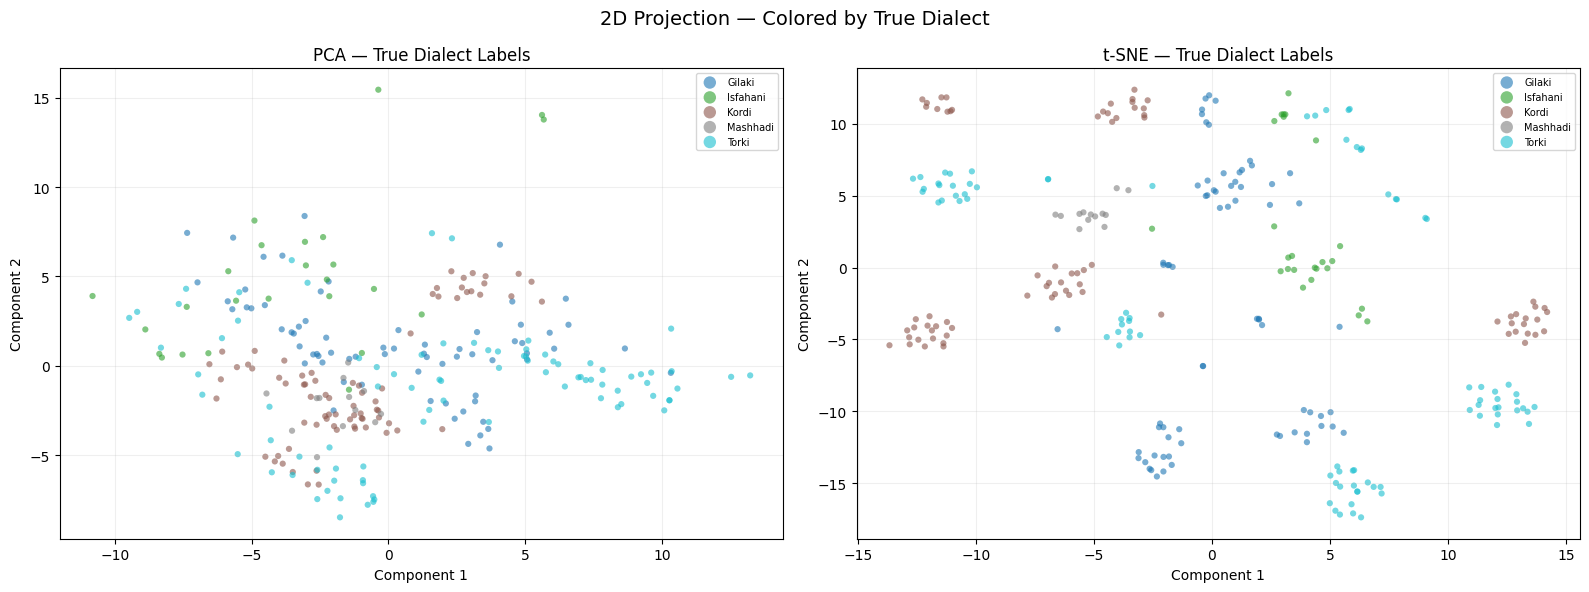

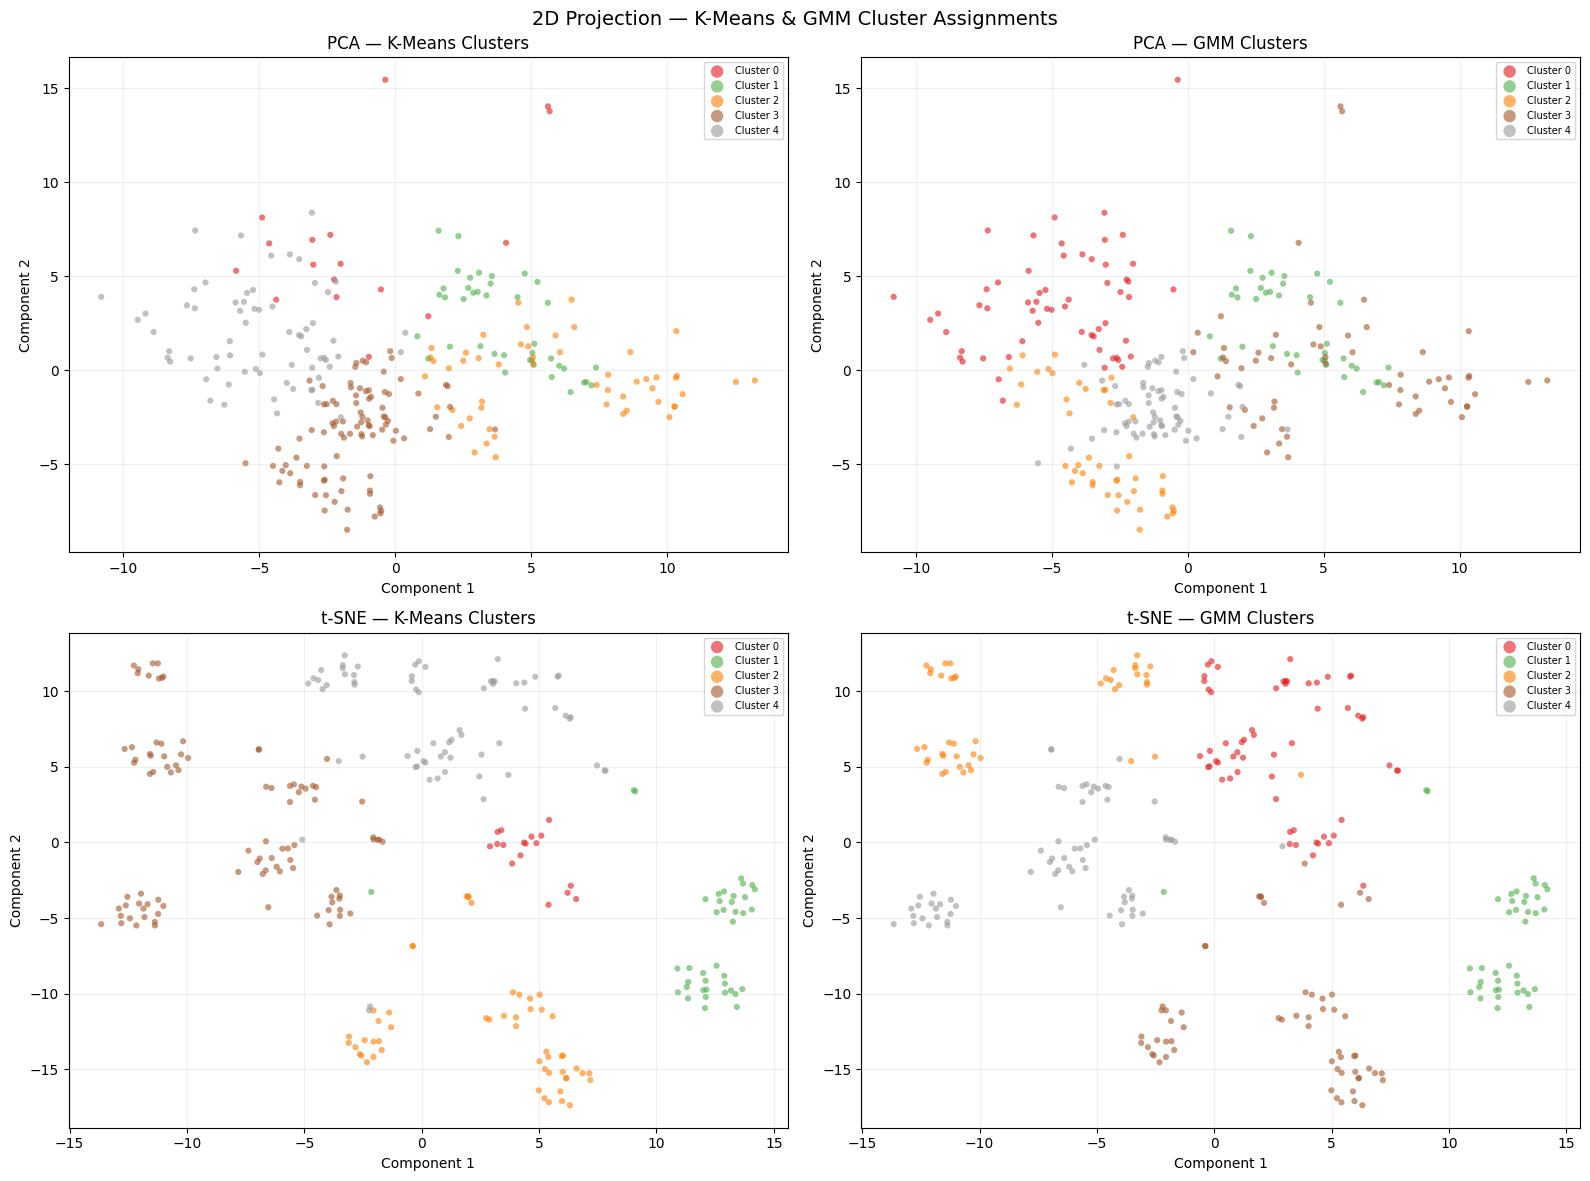

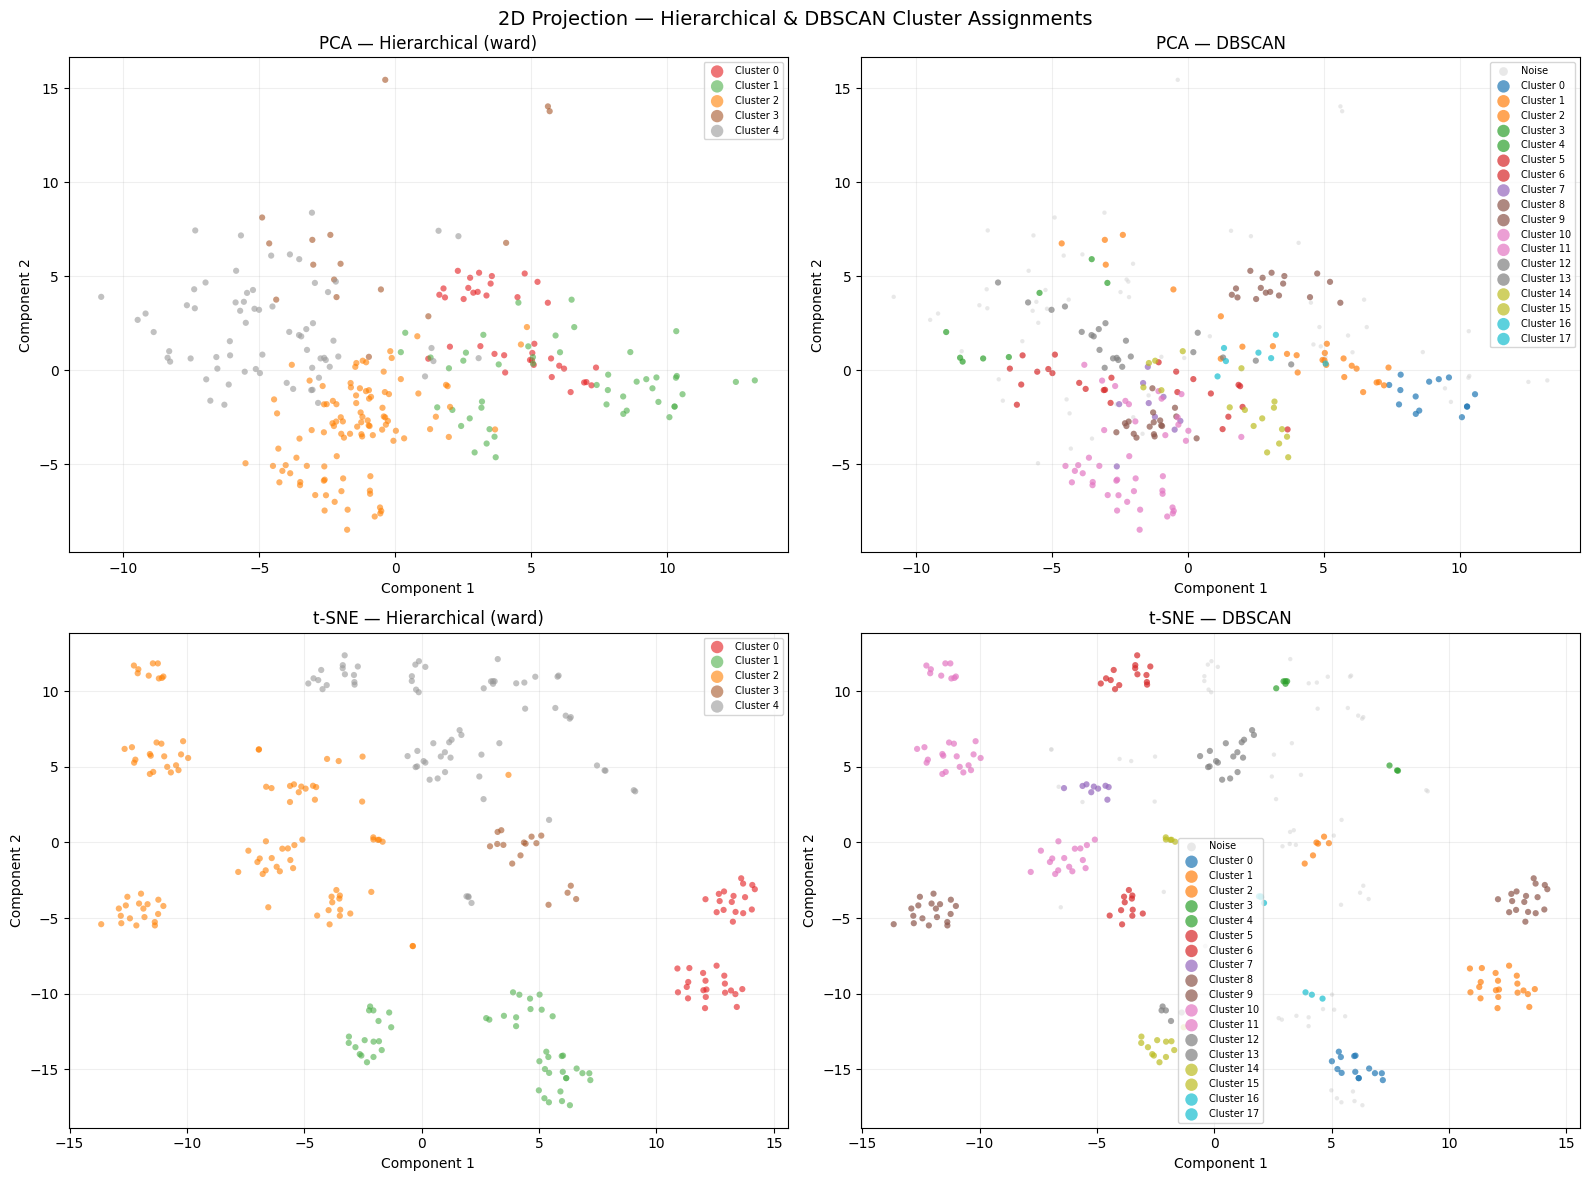

In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# Compute 2D PCA projection
pca_2d = PCA(n_components=2, random_state=42)
X_pca_2d = pca_2d.fit_transform(X_train_scaled)
print(f"PCA explained variance (2 components): "
      f"{pca_2d.explained_variance_ratio_.sum():.3f}")

# Compute 2D t-SNE projection
print("Running t-SNE (this may take a moment)...")
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_iter=1000)
X_tsne_2d = tsne.fit_transform(X_train_scaled)

# Build a consistent color map for dialect labels
unique_dialects = sorted(np.unique(true_labels))
color_map = plt.cm.get_cmap("tab10", len(unique_dialects))
dialect_to_color = {d: color_map(i) for i, d in enumerate(unique_dialects)}

# Row 1: true dialect labels
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, X_2d, title in [
    (axes[0], X_pca_2d,  "PCA — True Dialect Labels"),
    (axes[1], X_tsne_2d, "t-SNE — True Dialect Labels"),
]:
    for dialect in unique_dialects:
        mask = true_labels == dialect
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[dialect_to_color[dialect]], label=dialect,
                   alpha=0.6, s=20, edgecolors="none")
    ax.set_title(title)
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(fontsize=7, markerscale=2, loc="best")
    ax.grid(True, alpha=0.2)

plt.suptitle("2D Projection — Colored by True Dialect", fontsize=14)
plt.tight_layout()
plt.show()

# Row 2: K-Means and GMM cluster assignments
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
cluster_cmap = plt.cm.get_cmap("Set1", n_true_dialects)

for row, X_2d, proj_name in [
    (0, X_pca_2d,  "PCA"),
    (1, X_tsne_2d, "t-SNE"),
]:
    for col, (clust_labels, algo_name) in enumerate([
        (km_labels,  "K-Means"),
        (gmm_labels, "GMM"),
    ]):
        ax = axes[row][col]
        for cid in range(n_true_dialects):
            mask = clust_labels == cid
            ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                       c=[cluster_cmap(cid)], label=f"Cluster {cid}",
                       alpha=0.6, s=20, edgecolors="none")
        ax.set_title(f"{proj_name} — {algo_name} Clusters")
        ax.set_xlabel("Component 1")
        ax.set_ylabel("Component 2")
        ax.legend(fontsize=7, markerscale=2, loc="best")
        ax.grid(True, alpha=0.2)

plt.suptitle("2D Projection — K-Means & GMM Cluster Assignments", fontsize=14)
plt.tight_layout()
plt.show()

# Row 3: Hierarchical and DBSCAN cluster assignments
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

dbscan_labels_for_plot = best_dbscan_labels if n_clust_db >= 2 else km_labels
dbscan_title = "DBSCAN" if n_clust_db >= 2 else "K-Means (DBSCAN fallback)"
n_db_plot = len(set(dbscan_labels_for_plot))
db_cmap = plt.cm.get_cmap("tab10", n_db_plot)

for row, X_2d, proj_name in [
    (0, X_pca_2d,  "PCA"),
    (1, X_tsne_2d, "t-SNE"),
]:
    ax = axes[row][0]
    for cid in range(n_true_dialects):
        mask = best_hier_labels == cid
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[cluster_cmap(cid)], label=f"Cluster {cid}",
                   alpha=0.6, s=20, edgecolors="none")
    ax.set_title(f"{proj_name} — Hierarchical ({best_hier_method})")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.2)

    ax = axes[row][1]
    unique_cids = sorted(set(dbscan_labels_for_plot))
    for i, cid in enumerate(unique_cids):
        mask = dbscan_labels_for_plot == cid
        label = "Noise" if cid == -1 else f"Cluster {cid}"
        color = "lightgray" if cid == -1 else db_cmap(i)
        ax.scatter(X_2d[mask, 0], X_2d[mask, 1],
                   c=[color], label=label,
                   alpha=0.5 if cid == -1 else 0.7,
                   s=10 if cid == -1 else 20, edgecolors="none")
    ax.set_title(f"{proj_name} — {dbscan_title}")
    ax.set_xlabel("Component 1")
    ax.set_ylabel("Component 2")
    ax.legend(fontsize=7, markerscale=2)
    ax.grid(True, alpha=0.2)

plt.suptitle("2D Projection — Hierarchical & DBSCAN Cluster Assignments", fontsize=14)
plt.tight_layout()
plt.show()

## 7 — Per-Sample Silhouette Analysis

 The silhouette plot for the **best algorithm** (highest NMI) shows how well
 each individual sample fits its assigned cluster.

 - Bars extending to the **right** → sample is well-separated from neighbours
 - Bars extending to the **left** → sample may belong to the wrong cluster
 - The **red dashed line** marks the overall mean silhouette score


PER-SAMPLE SILHOUETTE — DBSCAN


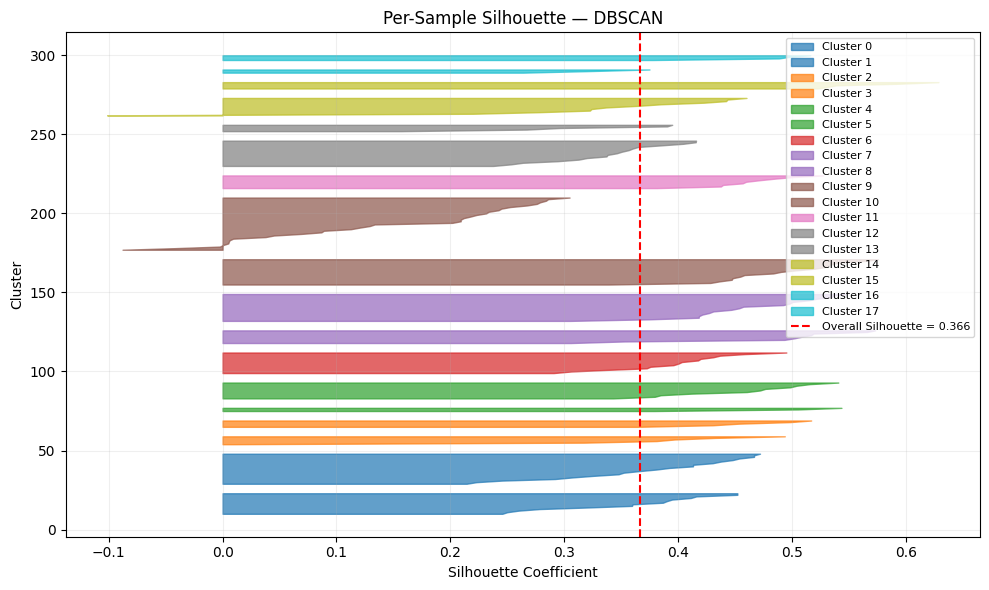

In [ ]:
from sklearn.metrics import silhouette_samples

print(f"PER-SAMPLE SILHOUETTE — {best_algo_name}")
print("=" * 60)

if -1 in best_algo_labels:
    mask = best_algo_labels != -1
    X_sil = X_train_scaled[mask]
    labels_sil = best_algo_labels[mask]
else:
    X_sil = X_train_scaled
    labels_sil = best_algo_labels

sample_sil_values = silhouette_samples(X_sil, labels_sil)
unique_clusters = sorted(set(labels_sil))  # دیگه -1 نداره
n_clusters_best = len(unique_clusters)

fig, ax = plt.subplots(figsize=(10, 6))
y_lower = 10
cluster_cmap2 = plt.cm.get_cmap("tab10", n_clusters_best)

for i, cid in enumerate(unique_clusters):
    sil_vals = np.sort(sample_sil_values[labels_sil == cid])
    y_upper = y_lower + sil_vals.shape[0]
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, sil_vals,
                     facecolor=cluster_cmap2(i), edgecolor=cluster_cmap2(i),
                     alpha=0.7, label=f"Cluster {cid}")
    y_lower = y_upper + 5

overall_sil = silhouette_score(X_sil, labels_sil)
ax.axvline(x=overall_sil, color="red", linestyle="--",
           label=f"Overall Silhouette = {overall_sil:.3f}")
ax.set_xlabel("Silhouette Coefficient")
ax.set_ylabel("Cluster")
ax.set_title(f"Per-Sample Silhouette — {best_algo_name}")
ax.legend(loc="upper right", fontsize=8)
ax.grid(True, alpha=0.2)
plt.tight_layout()
plt.show()

## Summary

 | Object | Description |
 |---|---|
 | `km_best` | Fitted KMeans — ready for joblib save |
 | `gmm_best` | Fitted GaussianMixture — ready for joblib save |
 | `scaler_clust` | StandardScaler fitted on `X_train_base` |
 | `best_algo_name` | Name of the best algorithm by NMI |
 | `best_algo_labels` | Cluster assignments from the best algorithm |


In [ ]:
print("Clustering section complete.")
print(f"   Best model for Clustering League : {best_algo_name}  (NMI = {best_algo_nmi:.4f})")
print(f"   km_best       → KMeans (k={n_true_dialects})")
print(f"   gmm_best      → GaussianMixture (n={n_true_dialects})")
print(f"   scaler_clust  → StandardScaler fitted on X_train_base")


Clustering section complete.
   Best model for Clustering League : DBSCAN  (NMI = 0.5176)
   km_best       → KMeans (k=5)
   gmm_best      → GaussianMixture (n=5)
   scaler_clust  → StandardScaler fitted on X_train_base
